# TESI

### Librerie

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os
import random
import warnings
import seaborn as sns
import pmdarima as pm
import tensorflow as tf
from scipy import stats
from scipy.stats import norm, shapiro, kruskal, friedmanchisquare
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch, normal_ad
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from arch.unitroot import PhillipsPerron
from tensorflow.keras import layers, Model
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, GRU, Input, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D, Subtract, Add
from tensorflow.keras.optimizers import Nadam
from statsmodels.tsa.statespace.sarimax import SARIMAX  
from PIL import Image

2026-04-01 18:30:09.232228: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-01 18:30:09.402992: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775061009.433582  131287 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775061009.445015  131287 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775061009.510169  131287 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Dataset: Permanenza media delle persone estere arrivate nelle strutture ricettive in Calabria

In [2]:
Df = pd.read_csv("Arrivi, Presenze e Permanenza Media.csv", encoding="latin1", sep=";")
df1 = Df.iloc[:, 2]   # Seleziona la colonna della permanenza media degli esteri
df1 = (df1.astype(str)
        .str.strip()
        .str.replace('.', '', regex=False)   # rimuove separatore migliaia
        .str.replace(',', '.', regex=False)  # converte decimale in formato US
     )
df1 = pd.to_numeric(df1, errors='coerce')  
df1.index = pd.date_range(start="2008-01", periods=len(df1), freq="M")  
df = df1[:204]

/tmp/ipykernel_131287/4236419259.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df1.index = pd.date_range(start="2008-01", periods=len(df1), freq="M")


### Plot della serie

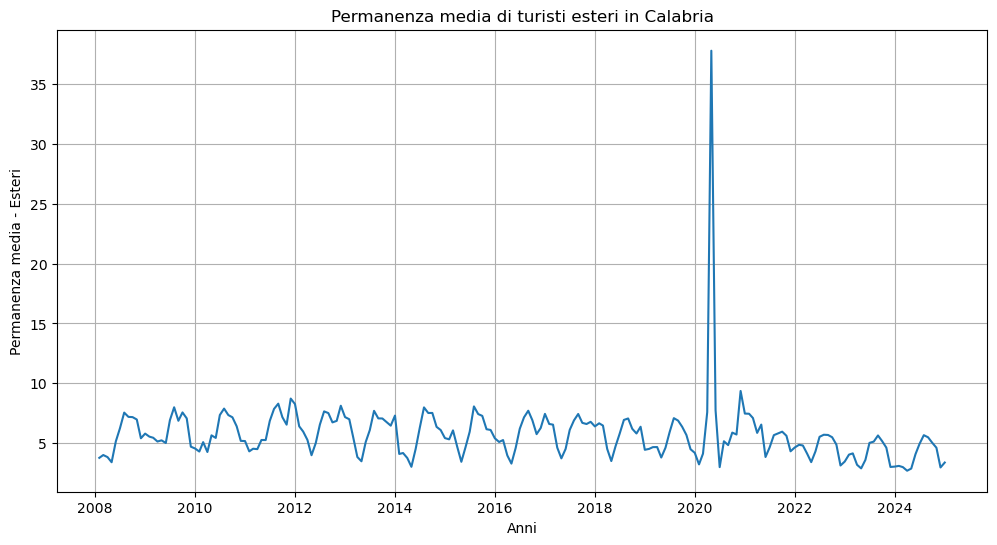

In [3]:
plt.figure(figsize=(12, 6))
plt.plot(df)
plt.title("Permanenza media di turisti esteri in Calabria")
plt.xlabel("Anni")
plt.ylabel("Permanenza media - Esteri")
plt.grid(True)
plt.savefig("Plot/permanenza_esteri.png", dpi=300, bbox_inches="tight")
plt.show()

### Statistiche descrittive

In [4]:
x = df.values  

print("Statistiche descrittive:")
print("Numero di osservazioni:", len(x))
print("Missing values:", np.sum(pd.isnull(x)))
print("Media:", np.mean(x))
print("Deviazione standard:", np.std(x, ddof=1))  # ddof=1 → stima campionaria
print("Varianza:", np.var(x, ddof=1))
print("Minimo:", np.min(x))
print("Massimo:", np.max(x))
print("Mediana:", np.median(x))
print("Quantili 25%-75%:", np.percentile(x, [25, 75]))
print("Intervallo interquartile (IQR):", np.percentile(x, 75) - np.percentile(x, 25))
print("Coefficiente di variazione (CV):", np.std(x, ddof=1) / np.mean(x))
print("Asimmetria (skewness):", pd.Series(x).skew())
print("Curtosi (kurtosis):", pd.Series(x).kurtosis())

Statistiche descrittive:
Numero di osservazioni: 204
Missing values: 0
Media: 5.7548823974607854
Deviazione standard: 2.6744294506011523
Varianza: 7.152572886242781
Minimo: 2.711989655
Massimo: 37.76
Mediana: 5.592256158
Quantili 25%-75%: [4.53200178 6.86952278]
Intervallo interquartile (IQR): 2.3375209915
Coefficiente di variazione (CV): 0.46472356268847215
Asimmetria (skewness): 8.475297334459146
Curtosi (kurtosis): 101.21377345816902


### Boxplot: distribuzione dei valori della serie mese per mese

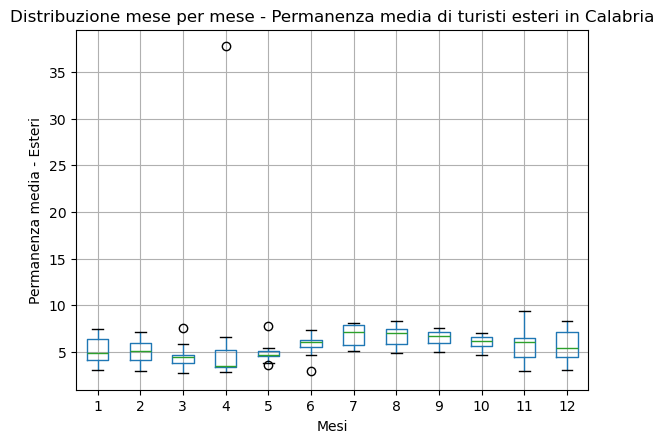

In [5]:
tmp = pd.DataFrame({"Y": df})
tmp["month"] = tmp.index.month
tmp.boxplot(column="Y", by="month")
plt.title("Distribuzione mese per mese - Permanenza media di turisti esteri in Calabria")
plt.suptitle("")
plt.xlabel("Mesi")
plt.ylabel("Permanenza media - Esteri")
plt.savefig("Plot/boxplot_permanenza_esteri.png", dpi=300, bbox_inches="tight")
plt.show()

## Funzione di autocorrelazione totale e parziale

<Figure size 1000x400 with 0 Axes>

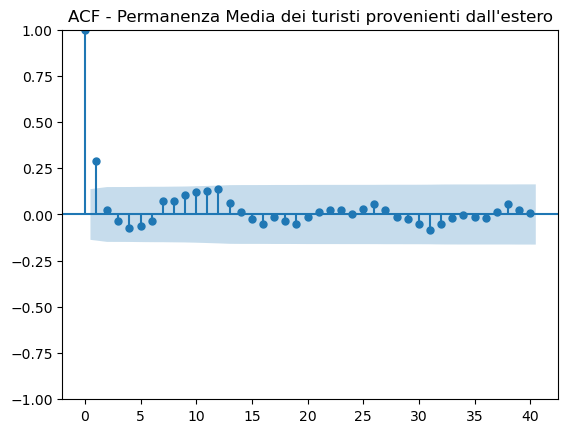

<Figure size 1000x400 with 0 Axes>

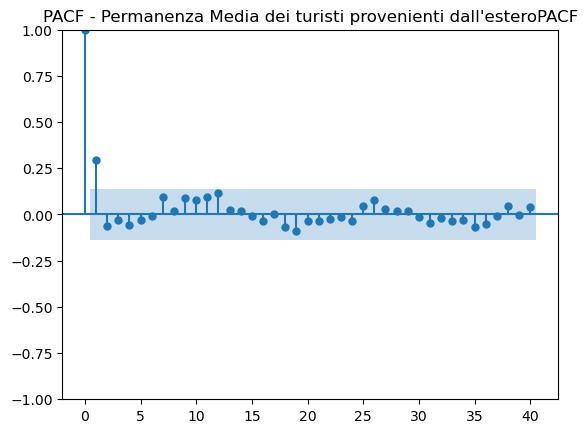

In [3]:
lags = 40

acf_vals = acf(df, nlags=lags, fft=True)
pacf_vals = pacf(df, nlags=lags, method="yw")  # oppure method="ols"

plt.figure(figsize=(10,4))
plot_acf(df, lags=lags)
plt.title("ACF - Permanenza Media dei turisti provenienti dall'estero")
plt.savefig("Plot/acf_permanenza_esteri.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(df, lags=lags, method="yw")
plt.title("PACF - Permanenza Media dei turisti provenienti dall'esteroPACF")
plt.savefig("Plot/pacf_permanenza_esteri.png", dpi=300, bbox_inches="tight")
plt.show()

### Test ADF

In [7]:
result = adfuller(df, maxlag=None, regression='c', autolag='AIC')

adf_stat, pvalue, usedlag, nobs, crit_vals, icbest = result
print("Test di Dickey-Fuller aumentato (ADF)")
print(f"ADF statistic   : {adf_stat:.4f}")
print(f"p-value         : {pvalue:.4f}")
print(f"Lags utilizzati : {usedlag}")
print(f"N obs           : {int(nobs)}")
print("Valori critici  :", {k: round(v,4) for k, v in crit_vals.items()})
print(f"IC (migliore)   : {icbest:.4f}")

Test di Dickey-Fuller aumentato (ADF)
ADF statistic   : -10.4817
p-value         : 0.0000
Lags utilizzati : 0
N obs           : 203
Valori critici  : {'1%': -3.463, '5%': -2.8759, '10%': -2.5744}
IC (migliore)   : 902.6309


### Test ADF, PP e KPSS

In [8]:
alpha = 0.05
results = []

# ADF
adf_res = adfuller(df, autolag="AIC")
adf_stat = adf_res[0]
adf_pval = adf_res[1]

results.append({
    "Test": "ADF",
    "Statistic": adf_stat,
    "p-value": adf_pval,
    "Null Hypothesis": "Unit root (non-stazionaria)",
    "Conclusione (5%)": "Stazionaria" if adf_pval < alpha else "Non stazionaria"
})

# Phillips–Perron (PP)
pp_res = PhillipsPerron(df)  # default: costante ("c")
pp_stat = pp_res.stat
pp_pval = pp_res.pvalue

results.append({
    "Test": "Phillips-Perron",
    "Statistic": pp_stat,
    "p-value": pp_pval,
    "Null Hypothesis": "Unit root (non-stazionaria)",
    "Conclusione (5%)": "Stazionaria" if pp_pval < alpha else "Non stazionaria"
})

# KPSS
# H0: la serie è STAZIONARIA (intorno a una costante, regressione='c')
kpss_stat, kpss_pval, kpss_lags, kpss_crit = kpss(df, regression='c', nlags="auto")

results.append({
    "Test": "KPSS",
    "Statistic": kpss_stat,
    "p-value": kpss_pval,
    "Null Hypothesis": "Stazionaria (intorno a costante)",
    "Conclusione (5%)": "Non stazionaria" if kpss_pval < alpha else "Stazionaria"
})

# TABELLA RIASSUNTIVA
summary_df = pd.DataFrame(results)
print(f"Test di stazionarietà sulla serie - Permanenza media delle persone provenienti dall'estero\n")
print(summary_df)

Test di stazionarietà sulla serie - Permanenza media delle persone provenienti dall'estero

              Test  Statistic       p-value                   Null Hypothesis  \
0              ADF -10.481724  1.208854e-18       Unit root (non-stazionaria)   
1  Phillips-Perron -10.534009  8.998525e-19       Unit root (non-stazionaria)   
2             KPSS   0.354161  9.691357e-02  Stazionaria (intorno a costante)   

  Conclusione (5%)  
0      Stazionaria  
1      Stazionaria  
2      Stazionaria  


### Differenziazione

In [9]:
# Se la serie non è stazionaria, differenzia e ripeti
if adf_pval > 0.05 or pp_pval > 0.05 or kpss_pval < 0.05:
    print("\nLa serie è NON stazionaria. Proviamo una differenza di ordine 12...")
    Y_diff = df.diff(12).dropna()

    #Plot della serie differenziata
    plt.figure(figsize=(10,4))
    plt.plot(Y_diff)
    plt.title("Serie differenziata (differenza di ordine 12)")
    plt.xlabel("Anni")
    plt.ylabel("Residui - Arrivi Italiani (differenziata)")
    plt.grid(True)
    plt.savefig("Plot/arrivi_italiani_differenziati.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ACF/PACF differenziata
    plt.figure(figsize=(10,4))
    plot_acf(Y_diff, lags=40)
    plt.title("ACF (serie differenziata)")
    plt.show()

    plt.figure(figsize=(10,4))
    plot_pacf(Y_diff, lags=40, method="yw")
    plt.title("PACF (serie differenziata)")
    plt.show()

    alpha = 0.05
    results = []

    # ADF
    adf_res = adfuller(Y_diff, autolag="AIC")
    adf_stat = adf_res[0]
    adf_pval = adf_res[1]

    results.append({
        "Test": "ADF",
        "Statistic": adf_stat,
        "p-value": adf_pval,
        "Null Hypothesis": "Unit root (non-stazionaria)",
        "Conclusione (5%)": "Stazionaria" if adf_pval < alpha else "Non stazionaria"
    })

    # Phillips–Perron (PP)
    pp_res = PhillipsPerron(Y_diff)  # default: costante ("c")
    pp_stat = pp_res.stat
    pp_pval = pp_res.pvalue

    results.append({
        "Test": "Phillips-Perron",
        "Statistic": pp_stat,
        "p-value": pp_pval,
        "Null Hypothesis": "Unit root (non-stazionaria)",
        "Conclusione (5%)": "Stazionaria" if pp_pval < alpha else "Non stazionaria"
    })

    # KPSS
    # H0: la serie è STAZIONARIA (intorno a una costante, regressione='c')
    kpss_stat, kpss_pval, kpss_lags, kpss_crit = kpss(Y_diff, regression='c', nlags="auto")

    results.append({
        "Test": "KPSS",
        "Statistic": kpss_stat,
        "p-value": kpss_pval,
        "Null Hypothesis": "Stazionaria (intorno a costante)",
        "Conclusione (5%)": "Non stazionaria" if kpss_pval < alpha else "Stazionaria"
    })

    # TABELLA RIASSUNTIVA 
    summary_df = pd.DataFrame(results)
    print(f"Test di stazionarietà sulla serie - Arrivi delle persone provenienti dall'Italia\n")
    print(summary_df)
    if adf_pval > 0.05 or pp_pval > 0.05 or kpss_pval < 0.05:
         print("La serie differenziata è ancora NON stazionaria.")
    else:
        print("La serie differenziata è stazionaria.")

## F-Test e ARCH-LM Test

In [34]:
n = len(df)
first = df[:n//2]
second = df[n//2:]

var1 = np.var(first, ddof=1)
var2 = np.var(second, ddof=1)

F_stat = var2 / var1      # rapporto delle varianze
df2 = len(second) - 1
df3 = len(first) - 1

p_one_side = 1 - stats.f.cdf(F_stat, df2, df3)
p_two_side = 2 * min(p_one_side, 1 - p_one_side)

print("Confronto varianze primi/secondi dati (F-test) - serie in scala originale")
print("Varianza prima metà:", var1)
print("Varianza seconda metà:", var2)
print("Statistica F:", F_stat)
print("p-value (bilaterale):", p_two_side)

if p_two_side < 0.05:
    print("\nLe varianze sono significativamente diverse: NON stazionaria in varianza (almeno a grandi linee).")
else:
    print("\nNon si rilevano differenze significative di varianza tra i due periodi.")

# Test ARCH LM (eteroschedasticità nel tempo)

resid = df - df.mean()  # residui centrati

lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(resid, nlags=10)

print("\nTest ARCH LM (Engle) sui residui centrati - serie in scala originale")
print("LM statistic:", lm_stat)
print("LM p-value:", lm_pvalue)
print("F statistic:", f_stat)
print("F p-value:", f_pvalue)

if lm_pvalue < 0.05:
    print("\nSi rifiuta H0 di 'no ARCH': la varianza condizionale NON è costante (eteroschedasticità).")
else:
    print("\nNon si rifiuta H0: non c'è evidenza forte di eteroschedasticità (varianza condizionale circa costante).")

Confronto varianze primi/secondi dati (F-test) - serie in scala originale
Varianza prima metà: 1.9438679594760209
Varianza seconda metà: 12.368865494946165
Statistica F: 6.363017320518135
p-value (bilaterale): 2.220446049250313e-16

Le varianze sono significativamente diverse: NON stazionaria in varianza (almeno a grandi linee).

Test ARCH LM (Engle) sui residui centrati - serie in scala originale
LM statistic: 0.06090110837727147
LM p-value: 0.9999999997872947
F statistic: 0.005746599265819029
F p-value: 0.9999999998227991

Non si rifiuta H0: non c'è evidenza forte di eteroschedasticità (varianza condizionale circa costante).


### Test di Ljung-Box e Box-Pierce

In [12]:
results = acorr_ljungbox(df, lags=[36], return_df=True, boxpierce=True)

print(results)

      lb_stat  lb_pvalue    bp_stat  bp_pvalue
36  43.299018   0.187937  41.066627   0.258175


### Lag Plot

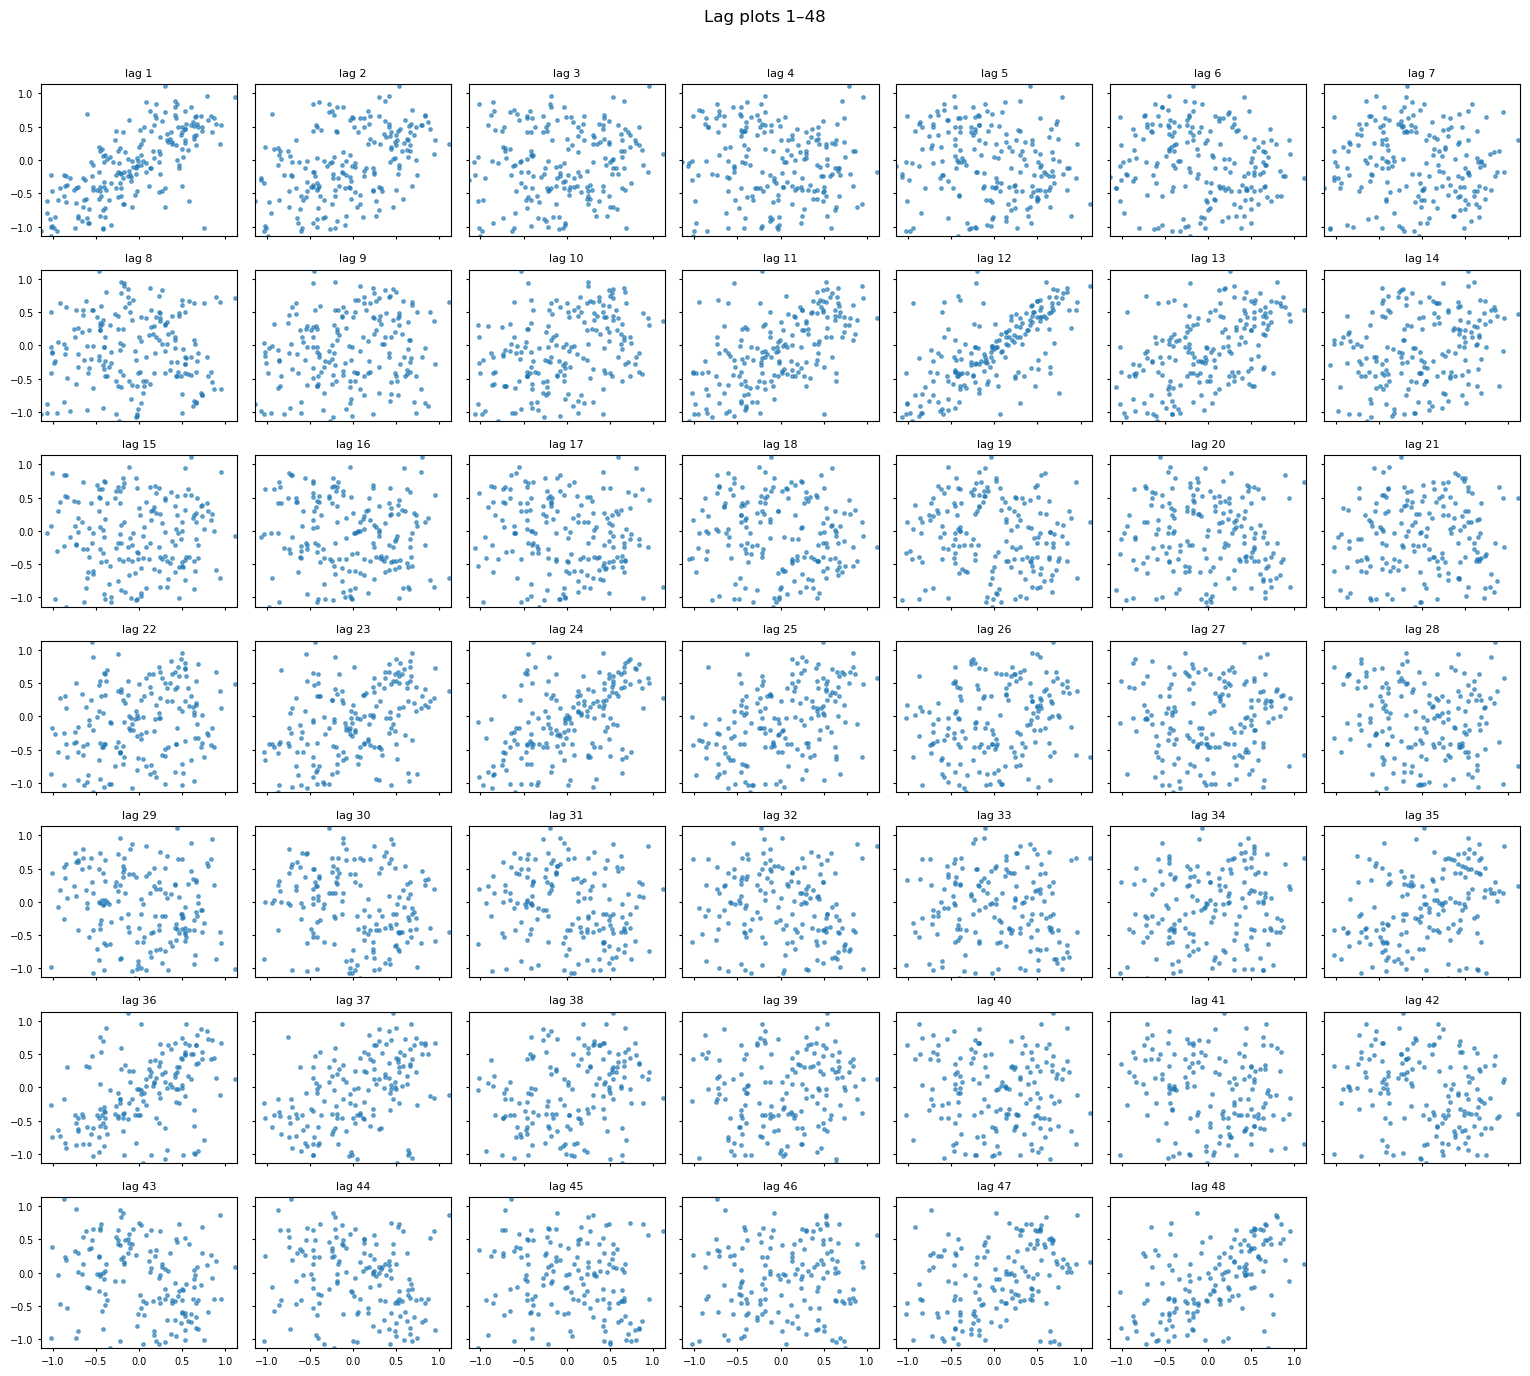

In [13]:
def lagplot_grid(y, max_lag=48, n_cols=7, standardize=True, s=6, alpha=0.6):
    y = pd.Series(y).dropna().astype(float)
    if standardize:
        y = (y - y.mean()) / y.std(ddof=1)

    n_rows = int(np.ceil(max_lag / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 2.2, n_rows * 2.0),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

    # limiti comuni (robusti agli outlier)
    lim = np.nanpercentile(np.abs(y), 99)
    lim = max(lim, 1.0)  # evita range troppo piccolo

    for k in range(1, max_lag + 1):
        ax = axes[k - 1]
        x = y.shift(k).dropna()
        ax.scatter(x, y.iloc[k:], s=s, alpha=alpha)
        ax.set_title(f"lag {k}", fontsize=8)
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.tick_params(labelsize=7, length=2)

    # nascondi assi in eccesso
    for j in range(max_lag, n_rows * n_cols):
        axes[j].axis("off")

    fig.suptitle(f"Lag plots 1–{max_lag}", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

lagplot_grid(df, max_lag=48, n_cols=7)

### Test di Kruskal-Wallis e Test di Friedman

In [14]:
def check_seasonality_robust(y, freq=12, alpha=0.05):
    # Preparazione dei gruppi (Mesi/Trimestri)
    # Crea un dataframe con l'indice temporale e i valori
    df = pd.DataFrame({'val': y.values})
    df['season'] = (np.arange(len(df)) % freq) + 1
    df['cycle'] = (np.arange(len(df)) // freq) + 1 # Identifica l'anno/blocco
    
    # TEST DI KRUSKAL-WALLIS
    # Verifica se almeno un periodo ha una distribuzione diversa dagli altri
    groups = [group['val'].values for name, group in df.groupby('season')]
    stat_kw, p_kw = kruskal(*groups)
    
    # TEST DI FRIEDMAN
    # Richiede che ogni "anno" (blocco) sia completo. 
    # Prende solo i cicli completi per evitare matrici sbilanciate.
    pivot_df = df.pivot(index='cycle', columns='season', values='val').dropna()
    
    if not pivot_df.empty and pivot_df.shape[0] >= 2:
        # Friedman lavora sulle colonne (stagioni) all'interno dei blocchi (anni)
        stat_f, p_f = friedmanchisquare(*[pivot_df[col] for col in pivot_df.columns])
    else:
        stat_f, p_f = np.nan, np.nan

    return {
        "is_seasonal": bool(p_kw < alpha or (not np.isnan(p_f) and p_f < alpha)),
        "kruskal_wallis": {"stat": stat_kw, "p_value": p_kw, "sig": p_kw < alpha},
        "friedman": {"stat": stat_f, "p_value": p_f, "sig": p_f < alpha if not np.isnan(p_f) else False},
        "samples_used": len(df),
        "complete_cycles": len(pivot_df)
    }

In [15]:
res = check_seasonality_robust(df, freq=12)
print(f"La serie è stagionale? {res['is_seasonal']}")
print(f"Kruskal-Wallis: stat = {res['kruskal_wallis']['stat']:.4f}, p-value = {res['kruskal_wallis']['p_value']:.4f}, significant = {res['kruskal_wallis']['sig']}")
print(f"Friedman: stat = {res['friedman']['stat']:.4f}, p-value = {res['friedman']['p_value']:.4f}, significant = {res['friedman']['sig']}")

La serie è stagionale? True
Kruskal-Wallis: stat = 72.9603, p-value = 0.0000, significant = True
Friedman: stat = 88.4208, p-value = 0.0000, significant = True


### Grafici della stagionalità

In [16]:
def seasonal_plot(Y, freq=12, start_year=2008, ylabel="Dati", title="Seasonal plot"):
    Y = pd.Series(Y).reset_index(drop=True)
    n = len(Y)
    n_years = n // freq
    
    # crea matrice anni x stagioni
    data = Y.values.reshape(n_years, freq)
    years = np.arange(start_year, start_year+n_years)

    plt.figure(figsize=(8,5))
    for i, row in enumerate(data):
        plt.plot(range(1, freq+1), row, marker="o", label=str(years[i]))
    plt.xticks(range(1, freq+1))
    plt.xlabel("Mesi")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(loc="upper left", fontsize=7, bbox_to_anchor=(1,1))
    plt.show()

In [17]:
def polar_seasonal_plot(Y, freq=12, start_year=2008, ylabel="Dati", title="Polar seasonal plot"):
    Y = pd.Series(Y).reset_index(drop=True)
    n = len(Y)
    n_years = n // freq
    data = Y.values.reshape(n_years, freq)
    years = np.arange(start_year, start_year+n_years)
    angles = np.linspace(0, 2*np.pi, freq, endpoint=False)
    plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)
    for i, row in enumerate(data):
        ax.plot(angles, row, marker="o", label=str(years[i]))
    ax.set_xticks(angles)
    ax.set_xticklabels([f"Q{q}" for q in range(1, freq+1)])
    ax.set_title(title, pad=25)   
    plt.legend(loc="upper right", fontsize=7, bbox_to_anchor=(1.22, 1))
    plt.show()

In [18]:
def seasonal_subseries_plot(Y, freq=12, ylabel="Dati", title="Seasonal subseries plot"):
    Y = pd.Series(Y).reset_index(drop=True)
    n = len(Y)
    months = (np.arange(n) % freq) + 1
    df = pd.DataFrame({"value": Y, "month": months})
    plt.figure(figsize=(8,5))
    for m in range(1, freq+1):
        subset = df[df["month"]==m]["value"].reset_index(drop=True)
        plt.plot(subset.index, subset.values, marker="o", label=f"M{m}")
    plt.xlabel("Anni")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(loc="upper left", fontsize=7, bbox_to_anchor=(1,1))
    plt.show()

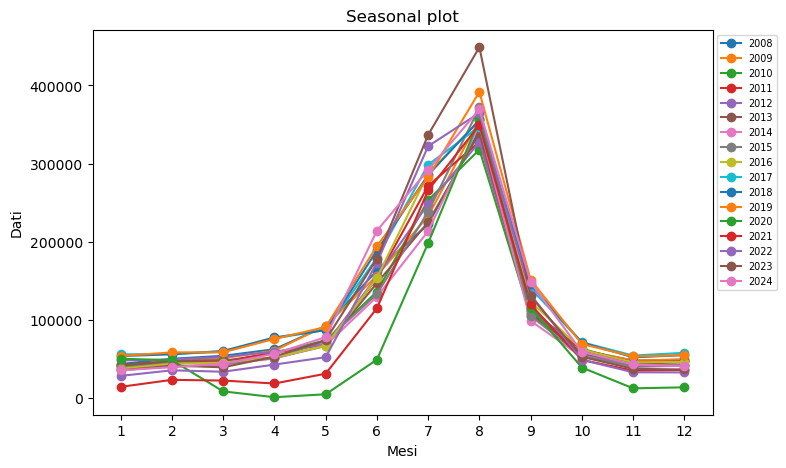

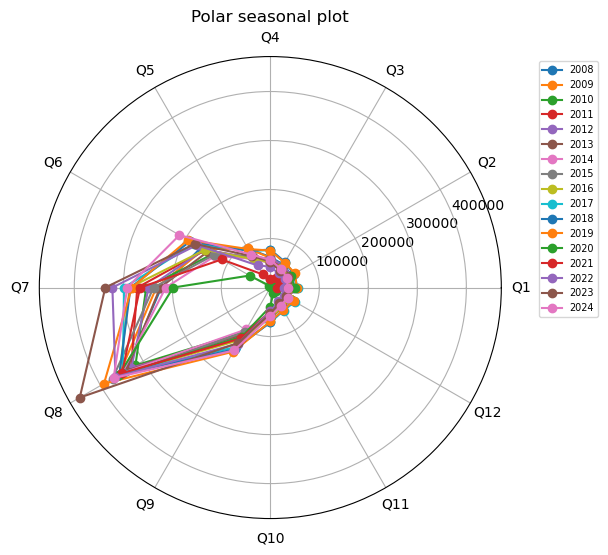

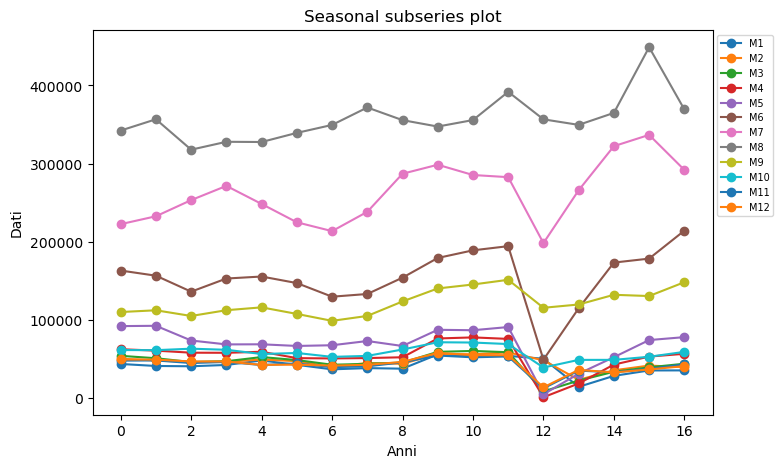

In [24]:
Y = df.astype(float).dropna()
n = len(Y)
n_years = n // 12   # anni interi
Y = Y.iloc[:n_years*12]  # tieni solo multiplo di 12

seasonal_plot(Y, freq=12, start_year=2008)
polar_seasonal_plot(Y, freq=12, start_year=2008)
seasonal_subseries_plot(Y, freq=12)

# Modello SARIMA

### Ricerca del modello con la funzione `auto_arima`, con dataset sia in scala originale che in scala log

In [19]:
model = pm.auto_arima(
    df,
    seasonal=True,
    m=12,
    stepwise=True,
    approximation=False,
    suppress_warnings=True,
    error_action='ignore',
    trace=False
)
print(f"Best ARIMA model: ARIMA{model.order} x Seasonal{model.seasonal_order} (m=12)")

Best ARIMA model: ARIMA(0, 0, 1) x Seasonal(0, 0, 1, 12) (m=12)


In [20]:
print(model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  204
Model:             SARIMAX(0, 0, 1)x(0, 0, 1, 12)   Log Likelihood                -479.088
Date:                            Mon, 16 Mar 2026   AIC                            966.176
Time:                                    23:00:57   BIC                            979.448
Sample:                                01-31-2008   HQIC                           971.545
                                     - 12-31-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      5.7384      0.561     10.232      0.000       4.639       6.838
ma.L1          0.2891      0.033   

### Residui dei modelli SARIMA generati dalla funzione `auto_arima`

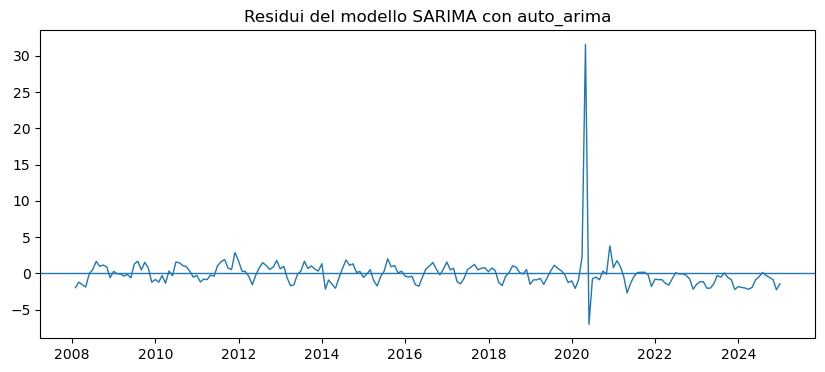

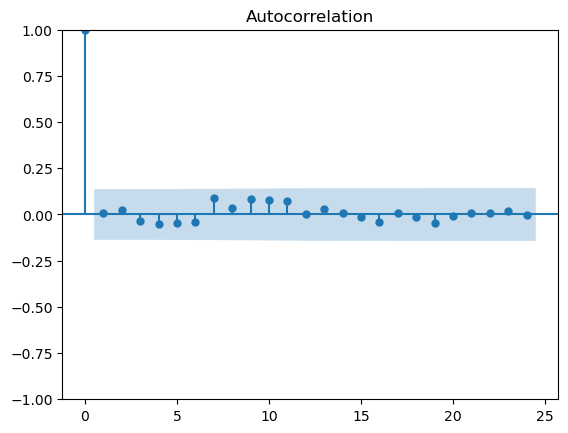


Ljung–Box test:
     lb_stat  lb_pvalue
12  8.008420   0.784472
24  9.256565   0.996996

Normalità (Anderson–Darling): stat=inf, p-value=0.000
Test ARCH: stat=0.486, p-value=1.000


In [21]:
# Serie in scala originale

eps = model.resid()
resid = pd.Series(eps)
resid_clean = resid.replace([float("inf"), float("-inf")], pd.NA).dropna()

# Plot residui
plt.figure(figsize=(10,4))
plt.plot(resid_clean, linewidth=1)
plt.title("Residui del modello SARIMA con auto_arima")
plt.axhline(0, linewidth=1)
plt.show()

# ACF residui
plot_acf(resid_clean, lags=24)
plt.show()

# Ljung–Box test
lb = acorr_ljungbox(resid_clean, lags=[12,24], return_df=True)
print("\nLjung–Box test:")
print(lb)

# Test di normalità (Anderson–Darling)
stat, pval = normal_ad(resid_clean)
print(f"\nNormalità (Anderson–Darling): stat={stat:.3f}, p-value={pval:.3f}")

# Test ARCH (eteroschedasticità, opzionale)
stat, pval, _, _ = het_arch(resid_clean)
print(f"Test ARCH: stat={stat:.3f}, p-value={pval:.3f}")

### Ricerca del miglior SARIMA con la funzione `SARIMAX`, usando i criteri AIC e BIC 

In [22]:
def best_sarima(y, p_range, d_range, q_range, P_range, D_range, Q_range, s=4):
    best_aic = np.inf
    best_bic = np.inf  
    best_result = None
    best_params = None
    
    for p in p_range:
        for d in d_range:
            for q in q_range:
                order = (p, d, q)
                for P in P_range:
                    for D in D_range:
                        for Q in Q_range:
                            seasonal = (P, D, Q, s)
                            try:
                                model = sm.tsa.SARIMAX(
                                    y,
                                    order=order,
                                    seasonal_order=seasonal,
                                    enforce_stationarity=False,
                                    enforce_invertibility=False
                                )
                                res = model.fit(disp=False)
                                if res.aic < best_aic and res.bic < best_bic:
                                    best_aic = res.aic
                                    best_bic = res.bic
                                    best_result = res
                                    best_params = (order, seasonal)
                            except Exception:
                                # ignora combinazioni non stimate / non convergenti
                                continue

    if best_result is None:
        raise RuntimeError("Nessun modello valido trovato: verifica i dati o allarga i range.")

    print("Miglior modello SARIMA trovato:")
    print(f"order={best_params[0]}, seasonal_order={best_params[1]}, "
          f"AIC={best_aic:.2f}, BIC={best_bic:.2f}")
    return best_result, best_params

In [23]:
best_model, best_params = best_sarima(
    df,
    p_range=range(0,3),
    d_range=range(0,2),
    q_range=range(0,3),
    P_range=range(0,2),
    D_range=range(0,2),
    Q_range=range(0,2),
    s=12  # stagionalità mensile
)

/home/antonio/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/antonio/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/antonio/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/antonio/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/antonio/anaconda3/lib/python3.12/site-packages/statsmo

Miglior modello SARIMA trovato:
order=(0, 1, 2), seasonal_order=(0, 1, 1, 12), AIC=875.79, BIC=888.48


/home/antonio/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [24]:
print(best_model.summary())

                                      SARIMAX Results                                       
Dep. Variable:              PERMANENZA MEDIA ESTERI   No. Observations:                  204
Model:             SARIMAX(0, 1, 2)x(0, 1, [1], 12)   Log Likelihood                -433.897
Date:                              Mon, 16 Mar 2026   AIC                            875.795
Time:                                      23:03:55   BIC                            888.477
Sample:                                  01-31-2008   HQIC                           880.938
                                       - 12-31-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.6982      0.036    -19.201      0.000      -0.770      -0.627
ma.L2         -0.25

### Residui del SARIMA generato dalla funzione `SARIMAX`

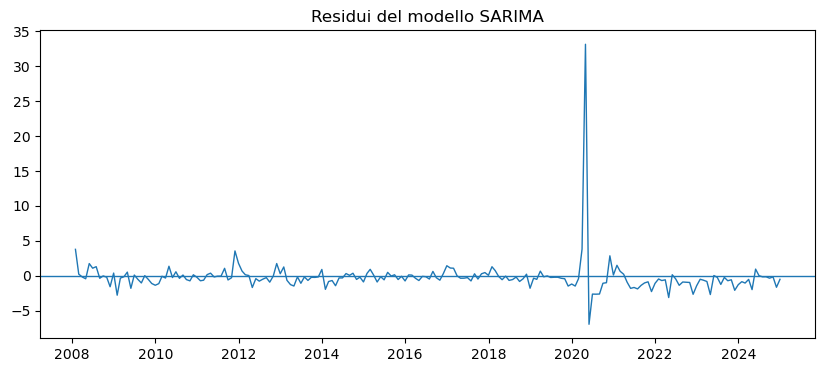

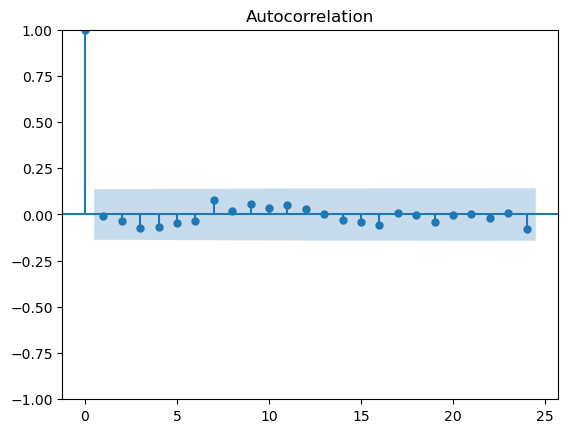


Ljung–Box test:
     lb_stat  lb_pvalue
12  6.155292   0.908052
24  9.267254   0.996968

Normalità (Anderson–Darling): stat=inf, p-value=0.000
Test ARCH: stat=0.523, p-value=1.000


In [25]:
resid = best_model.resid.dropna()

# Plot residui
plt.figure(figsize=(10,4))
plt.plot(resid, linewidth=1)
plt.title("Residui del modello SARIMA")
plt.axhline(0, linewidth=1)
plt.show()

# ACF residui
plot_acf(resid, lags=24)
plt.show()

# Ljung–Box test
lb = acorr_ljungbox(resid, lags=[12,24], return_df=True)
print("\nLjung–Box test:")
print(lb)

# Test di normalità (Anderson–Darling)
stat, pval = normal_ad(resid)
print(f"\nNormalità (Anderson–Darling): stat={stat:.3f}, p-value={pval:.3f}")

# Test ARCH (eteroschedasticità, opzionale)
stat, pval, _, _ = het_arch(resid)
print(f"Test ARCH: stat={stat:.3f}, p-value={pval:.3f}")

## Previsioni con il miglior SARIMA

### Setup, Intervalli Bootstrap e Metriche di errore

In [3]:
# Setup - SEEDING E RIPRODUCIBILITÀ

SEED = 12345
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

def bootstrap_ci(y_true, y_pred, metric_func, n_bootstrap=1000, ci=0.95):
    rng = np.random.default_rng(12345)
    stats = []
    n = len(y_true)
    for _ in range(n_bootstrap):
        idxs = rng.choice(n, n, replace=True)
        sample_true = y_true[idxs]
        sample_pred = y_pred[idxs]
        stats.append(metric_func(sample_true, sample_pred))
    lower = np.percentile(stats, (1 - ci) / 2 * 100)
    upper = np.percentile(stats, (1 + ci) / 2 * 100)
    return lower, upper

def compute_metrics(y_true_test, final_pred_test, y_train_scale=None, m=12, eps=1e-8):
    
    # Converte in array 1D
    y_true = np.asarray(y_true_test, dtype=float).ravel()
    y_pred = np.asarray(final_pred_test, dtype=float).ravel()

    # Metriche 
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100 # (NB: esplode se y_true ~ 0)

    # sMAPE (più robusto del MAPE)
    smape = np.mean(
        2.0 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + eps)
    ) * 100

    # MASE 
    mase = None
    if y_train_scale is not None:
        y_scale = np.asarray(y_train_scale, dtype=float).ravel()
        if len(y_scale) <= m:
            raise ValueError(f"y_train_scale deve avere lunghezza > m (m={m}).")
        # MAE del naive stagionale: |y_t - y_{t-m}|
        scale = np.mean(np.abs(y_scale[m:] - y_scale[:-m]))
        # Evita divisione per 0 se serie quasi costante
        mase = mae / (scale + eps)

    # Bootstrap CI 
    mae_ci = bootstrap_ci(y_true, y_pred, mean_absolute_error)
    mse_ci = bootstrap_ci(y_true, y_pred, mean_squared_error)
    rmse_ci = bootstrap_ci(y_true, y_pred,
                           lambda a, b: np.sqrt(mean_squared_error(a, b)))
    mape_ci = bootstrap_ci(y_true, y_pred,
                           lambda a, b: np.mean(np.abs((a - b) / (a + eps))) * 100)
    smape_ci = bootstrap_ci(y_true, y_pred,
                            lambda a, b: np.mean(
                                2.0 * np.abs(a - b) / (np.abs(a) + np.abs(b) + eps)
                            ) * 100)

    # MASE CI: bootstrap solo al numeratore (test) ma scala fissa da y_train_scale
    mase_ci = (None, None)
    if y_train_scale is not None:
        y_scale = np.asarray(y_train_scale, dtype=float).ravel()
        scale = np.mean(np.abs(y_scale[m:] - y_scale[:-m])) + eps
        mase_ci = bootstrap_ci(y_true, y_pred,
                               lambda a, b: mean_absolute_error(a, b) / scale)

    # Print 
    print(f"MAE = {mae:.3f}  MSE = {mse:.3f}  RMSE = {rmse:.3f}  "
          f"MAPE = {mape:.2f}%  sMAPE = {smape:.2f}%"
          + (f"  MASE = {mase:.3f}" if mase is not None else ""))

    print(f"    95% CI MAE  : [{mae_ci[0]:.3f}, {mae_ci[1]:.3f}]")
    print(f"    95% CI MSE  : [{mse_ci[0]:.3f}, {mse_ci[1]:.3f}]")
    print(f"    95% CI RMSE : [{rmse_ci[0]:.3f}, {rmse_ci[1]:.3f}]")
    if mase is not None:
        print(f"    95% CI MASE : [{mase_ci[0]:.3f}, {mase_ci[1]:.3f}]")
    print(f"    95% CI MAPE : [{mape_ci[0]:.2f}, {mape_ci[1]:.2f}]")
    print(f"    95% CI sMAPE: [{smape_ci[0]:.2f}, {smape_ci[1]:.2f}]")

    # Dict
    metrics_dict = {
        "MAE": mae, "MAE_low": mae_ci[0], "MAE_high": mae_ci[1],
        "MSE": mse, "MSE_low": mse_ci[0], "MSE_high": mse_ci[1],
        "RMSE": rmse, "RMSE_low": rmse_ci[0], "RMSE_high": rmse_ci[1],
        "MAPE": mape, "MAPE_low": mape_ci[0], "MAPE_high": mape_ci[1],
        "sMAPE": smape, "sMAPE_low": smape_ci[0], "sMAPE_high": smape_ci[1],
    }
    if mase is not None:
        metrics_dict.update({
            "MASE": mase, "MASE_low": mase_ci[0], "MASE_high": mase_ci[1],
            "MASE_m": m
        })

    return metrics_dict

### Previsione

Numero di osservazioni: 204
Train: 144, Validation: 60
                                      SARIMAX Results                                       
Dep. Variable:              PERMANENZA MEDIA ESTERI   No. Observations:                  144
Model:             SARIMAX(0, 1, 2)x(0, 1, [1], 12)   Log Likelihood                -128.242
Date:                              Wed, 01 Apr 2026   AIC                            264.484
Time:                                      18:33:12   BIC                            275.498
Sample:                                  01-31-2008   HQIC                           268.955
                                       - 12-31-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4721      0.094     -5.014

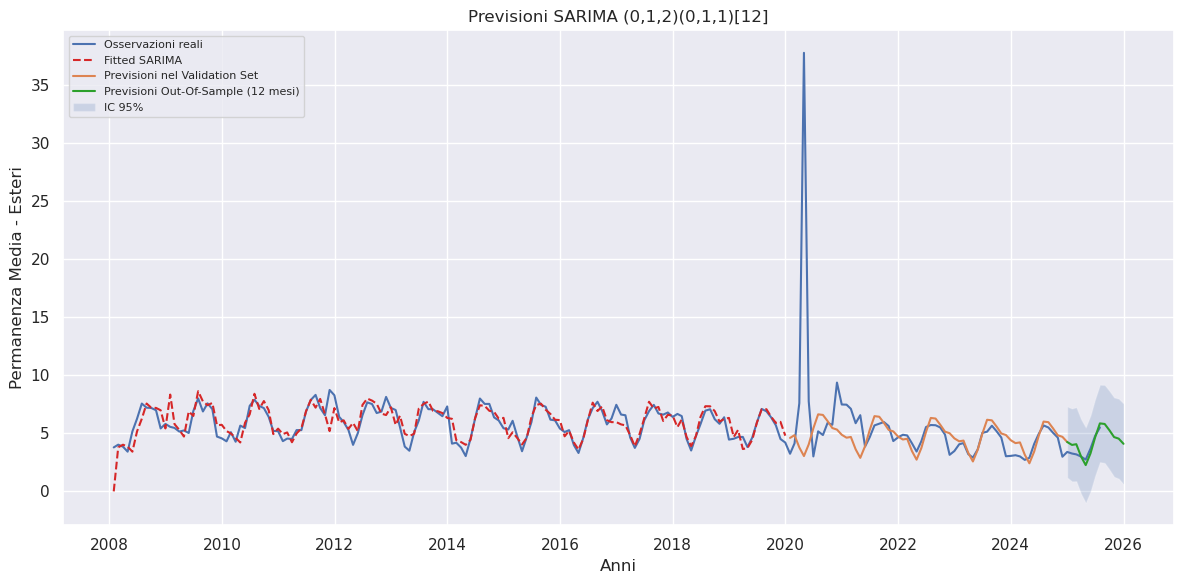

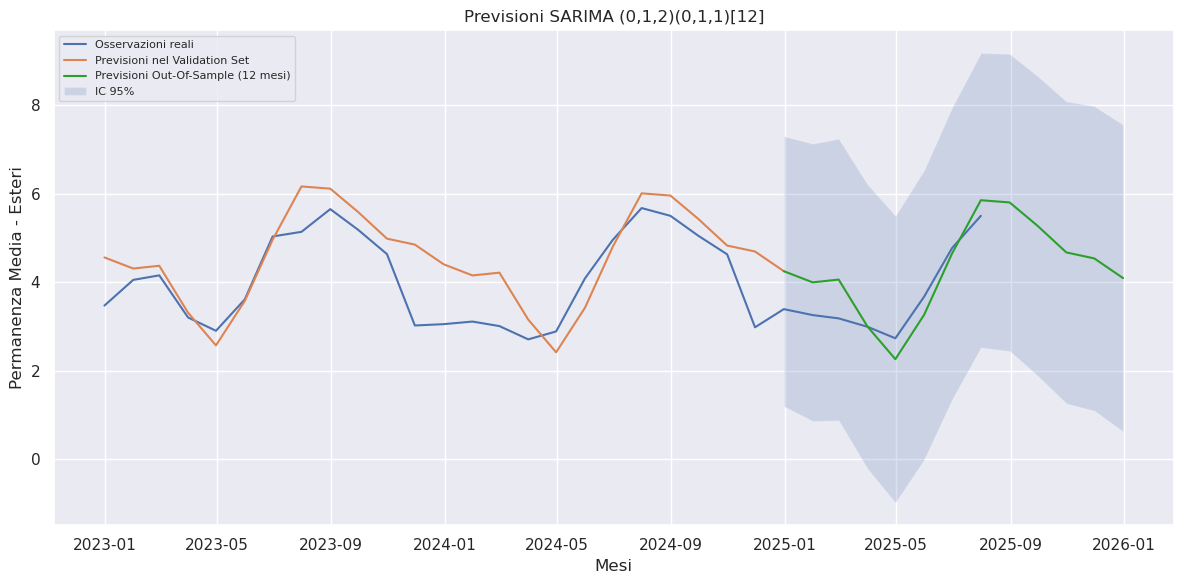

In [5]:
# Parametri e split 

n = len(df)

# Train-test split: ultimi 5 anni (60 mesi) per il validation set, resto
# (12 anni, 144 mesi) per il training.

nV = 60
nT = n - nV

training_set = df.iloc[:nT]
validation_set = df.iloc[nT:]

print(f"Numero di osservazioni: {n}")
print(f"Train: {nT}, Validation: {nV}")

# Modellazione 
# include.mean = FALSE  ->  trend='n' (no trend, no intercept)
model_train = SARIMAX(
    training_set,
    order=(0, 1, 2),
    seasonal_order=(0, 1, 1, 12),
    trend='n',
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_train = model_train.fit(disp=False)
print(results_train.summary())

# Fitted values sul training
fitted = results_train.fittedvalues

# allinea solo alla parte training
fitted_train = fitted.iloc[:nT]
training_plot = df.iloc[:nT]

# Forecast sul validation set
future_steps = 12
n_steps = nV + future_steps
forecast_res = results_train.get_forecast(steps=n_steps)

# previsione puntuale
y_pred = forecast_res.predicted_mean
print("\nPrevisioni sul validation set:")
print(y_pred[:n_steps-12])
print("\nPrevisioni future:")
print(y_pred[nV:])
print("\nVeri Valori: ")
print(df1[204:211].to_string())

# intervalli di confidenza (qui solo uno, es. 95%)
conf_int_95 = forecast_res.conf_int(alpha=0.05)

print(conf_int_95.head())      # mostra primi 5 intervalli di confidenza

# Prende le colonne per posizione (0 = lower, 1 = upper)
lower_95 = conf_int_95.iloc[:, 0]
upper_95 = conf_int_95.iloc[:, 1]

# Accuracy sul validation set (primi nV mesi)
# separa validation e future forecast
y_pred_validation = y_pred.iloc[:nV]
y_pred_future = y_pred.iloc[nV:]
metrics = compute_metrics(validation_set, y_pred_validation , y_train_scale=training_set, m=12)

# Plot osservazioni reali vs previsioni (con IC 95%)
plt.figure(figsize=(12, 6))

df_plot = df1.iloc # mostra solo gli ultimi 8 anni (96 mesi) per evidenziare meglio la parte di validation
y_pred_plot = y_pred.iloc[:60] # mostra solo la parte di validation 
y_future_plot = y_pred.iloc[59:] # mostra solo la parte di forecast futuro (12 mesi dopo la fine del validation)

plt.plot(df1.index, df1.values, label='Osservazioni reali')

plt.plot(fitted_train.index, fitted_train.values, linestyle="--", label="Fitted SARIMA", color="tab:red")

# Previsioni solo sulla parte di validation
plt.plot(y_pred_plot.index, y_pred_plot.values, label='Previsioni nel Validation Set')

# Previsioni future (12 mesi dopo la fine del validation)
plt.plot(y_future_plot.index, y_future_plot.values, label='Previsioni Out-Of-Sample (12 mesi)', color = "tab:green")

# Banda di confidenza 95%
plt.fill_between(y_pred.index[59:], lower_95[59:], upper_95[59:], alpha=0.2, label='IC 95%')

plt.title("Previsioni SARIMA (0,1,2)(0,1,1)[12]")
plt.xlabel("Anni")
plt.ylabel("Permanenza Media - Esteri")
plt.legend(loc = "upper left", fontsize = 8)
plt.tight_layout()
plt.savefig("Plot/pme_sarima.png", dpi=300, bbox_inches="tight")
plt.show()

# Zoom

plt.figure(figsize=(12, 6))
df_plot = df1.iloc[179:]
y_pred_plot = y_pred.iloc[35:60]
y_future_plot = y_pred.iloc[59:]

plt.plot(df_plot.index, df_plot.values, label='Osservazioni reali')
plt.plot(y_pred_plot.index, y_pred_plot.values, label='Previsioni nel Validation Set')
plt.plot(y_future_plot.index, y_future_plot.values, label='Previsioni Out-Of-Sample (12 mesi)', color = "tab:green")

# Banda di confidenza 95%
plt.fill_between(y_pred.index[59:], lower_95[59:], upper_95[59:], alpha=0.2, label='IC 95%')

plt.title("Previsioni SARIMA (0,1,2)(0,1,1)[12]")
plt.xlabel("Mesi")
plt.ylabel("Permanenza Media - Esteri")
plt.legend(loc = "upper left", fontsize = 8)
plt.tight_layout()
plt.savefig("Plot/pme_sarima_zoom.png", dpi=300, bbox_inches="tight")
plt.show()

# Salvataggio risultati

metrics_df = pd.DataFrame([metrics])
file_path = os.path.join("Metrics", "sarima_permanenza_media_esteri_metrics.csv")
metrics_df.to_csv(file_path, index=False)

forecasts_df = pd.DataFrame({"forecast": y_pred[60:]})
file_path = os.path.join("Forecasts", "sarima_permanenza_media_esteri_forecasts.csv")
forecasts_df.to_csv(file_path, index=False)

### Usando tutto il dataset per stimare

                                      SARIMAX Results                                       
Dep. Variable:              PERMANENZA MEDIA ESTERI   No. Observations:                  204
Model:             SARIMAX(0, 1, 2)x(0, 1, [1], 12)   Log Likelihood                -433.897
Date:                              Wed, 01 Apr 2026   AIC                            875.795
Time:                                      18:34:33   BIC                            888.477
Sample:                                  01-31-2008   HQIC                           880.938
                                       - 12-31-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.6982      0.036    -19.201      0.000      -0.770      -0.627
ma.L2         -0.25

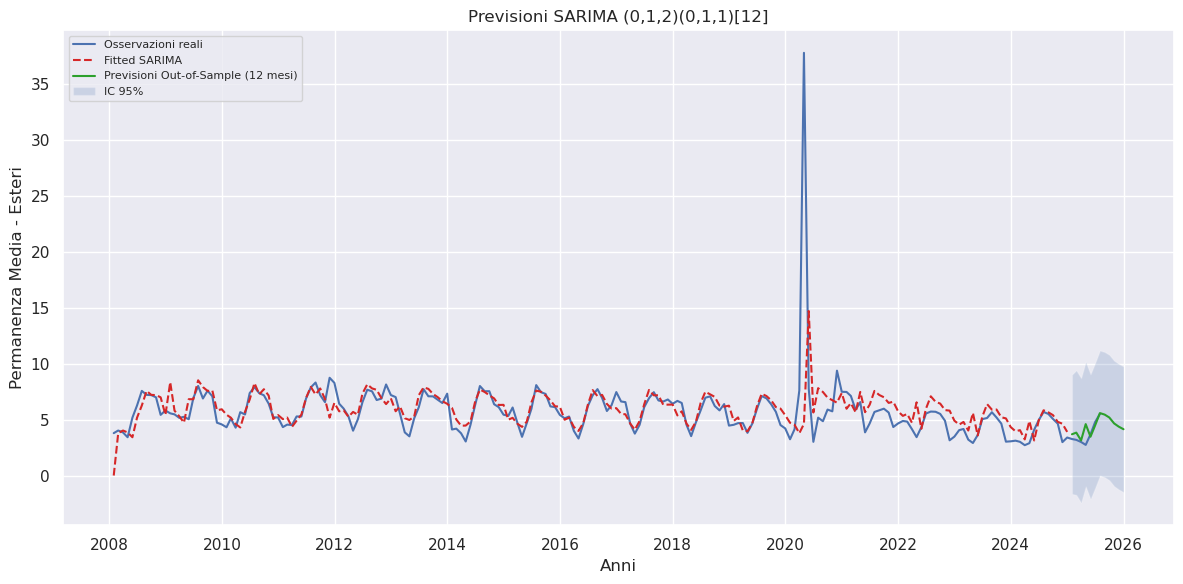

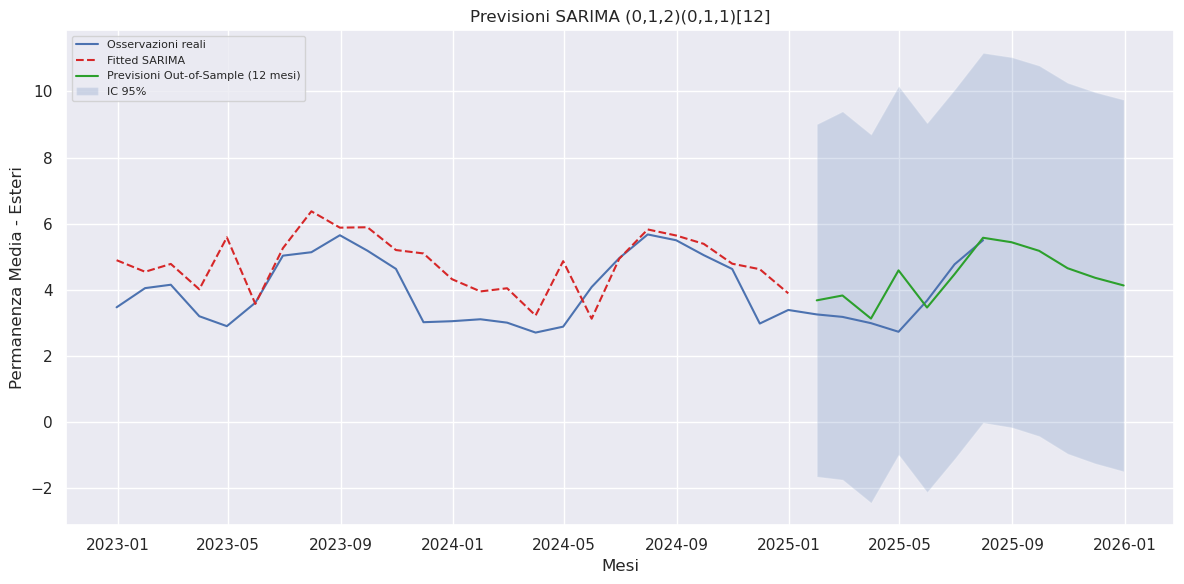

In [6]:
n = len(df)

# Modellazione 
# include.mean = FALSE  ->  trend='n' (no trend, no intercept)
model_train = SARIMAX(
    df,
    order=(0, 1, 2),
    seasonal_order=(0, 1, 1, 12),
    trend='n',
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_train = model_train.fit(disp=False)
print(results_train.summary())

# Fitted values sul training
fitted = results_train.fittedvalues

# allinea solo alla parte training
fitted_train = fitted.iloc[:n]
training_plot = df.iloc[:n]

# Forecast sul validation set
future_steps = 12
n_steps = nV + future_steps
forecast_res = results_train.get_forecast(steps=12)

# previsione puntuale
y_pred = forecast_res.predicted_mean
print("\nPrevisioni future:")
print(y_pred)
print("\nVeri Valori: ")
print(df1[204:211].to_string())

# intervalli di confidenza (qui solo uno, es. 95%)
conf_int_95 = forecast_res.conf_int(alpha=0.05)

print(conf_int_95.head())      # mostra primi 5 intervalli di confidenza

# Prende le colonne per posizione (0 = lower, 1 = upper)
lower_95 = conf_int_95.iloc[:, 0]
upper_95 = conf_int_95.iloc[:, 1]

# Metriche (solo relative alle 7 reali non considerate nel training)

y_true_oos = df1.iloc[204:]  # adatta il range ai mesi reali disponibili
y_pred_oos = y_pred.iloc[:len(y_true_oos)]           # allinea le previsioni

metrics = compute_metrics(
    y_true_test   = y_true_oos,
    final_pred_test = y_pred_oos,
    y_train_scale = df.values,   # serie di training per la scala del MASE
    m             = 12
)

# Plot osservazioni reali vs previsioni (con IC 95%)
plt.figure(figsize=(12, 6))

plt.plot(df1.index, df1.values, label='Osservazioni reali')
plt.plot(fitted_train.index, fitted_train.values, linestyle="--", label="Fitted SARIMA", color="tab:red")

# Previsioni Out-Of-Sample
plt.plot(y_pred.index, y_pred.values, label='Previsioni Out-of-Sample (12 mesi)', color = "tab:green")

# Banda di confidenza 95%
plt.fill_between(y_pred.index, lower_95, upper_95, alpha=0.2, label='IC 95%')

plt.title("Previsioni SARIMA (0,1,2)(0,1,1)[12]")
plt.xlabel("Anni")
plt.ylabel("Permanenza Media - Esteri")
plt.legend(loc = "upper left", fontsize = 8)
plt.tight_layout()
plt.savefig("Plot/pme_full_sarima.png", dpi=300, bbox_inches="tight")
plt.show()

# Zoom

plt.figure(figsize=(12, 6))
df_plot = df1.iloc[179:]
fitted_plot = fitted_train.iloc[179:]

plt.plot(df_plot.index, df_plot.values, label='Osservazioni reali')
plt.plot(fitted_plot.index, fitted_plot.values, linestyle="--", label="Fitted SARIMA", color="tab:red")
plt.plot(y_pred.index, y_pred.values, label='Previsioni Out-of-Sample (12 mesi)', color = "tab:green")

# Banda di confidenza 95%
plt.fill_between(y_pred.index, lower_95, upper_95, alpha=0.2, label='IC 95%')

plt.title("Previsioni SARIMA (0,1,2)(0,1,1)[12]")
plt.xlabel("Mesi")
plt.ylabel("Permanenza Media - Esteri")
plt.legend(loc = "upper left", fontsize = 8)
plt.tight_layout()
plt.savefig("Plot/pme_full_sarima_zoom.png", dpi=300, bbox_inches="tight")
plt.show()

# Salvataggio risultati

metrics_df = pd.DataFrame([metrics])
file_path = os.path.join("Metrics", "sarima_full_permanenza_media_esteri_metrics.csv")
metrics_df.to_csv(file_path, index=False)

forecasts_df = pd.DataFrame({"forecast": y_pred[60:]})
file_path = os.path.join("Forecasts", "sarima_full_permanenza_media_esteri_forecasts.csv")
forecasts_df.to_csv(file_path, index=False)

### Con Expanding Window

Numero di osservazioni: 204
Punti in expanding-test: 60
MAE = 3.083  MSE = 78.811  RMSE = 8.878  MAPE = 48.57%  sMAPE = 32.36%  MASE = 4.888
    95% CI MAE  : [1.376, 5.622]
    95% CI MSE  : [3.178, 212.515]
    95% CI RMSE : [1.783, 14.578]
    95% CI MASE : [2.182, 8.913]
    95% CI MAPE : [28.79, 78.60]
    95% CI sMAPE: [24.66, 41.37]

Previsioni sul validation set:
2020-01-31     4.604073
2020-02-29     4.024099
2020-03-31     3.489524
2020-04-30     5.063617
2020-05-31    63.288733
2020-06-30     5.460344
2020-07-31     6.844502
2020-08-31     6.706149
2020-09-30     6.174958
2020-10-31     5.800932
2020-11-30     4.444448
2020-12-31     5.487508
2021-01-31     4.168129
2021-02-28     5.381670
2021-03-31     7.504760
2021-04-30    26.287340
2021-05-31     4.580136
2021-06-30     5.614812
2021-07-31     6.927841
2021-08-31     6.707999
2021-09-30     6.587603
2021-10-31     6.131998
2021-11-30     6.784249
2021-12-31     5.554077
2022-01-31     5.449681
2022-02-28     5.595657
20

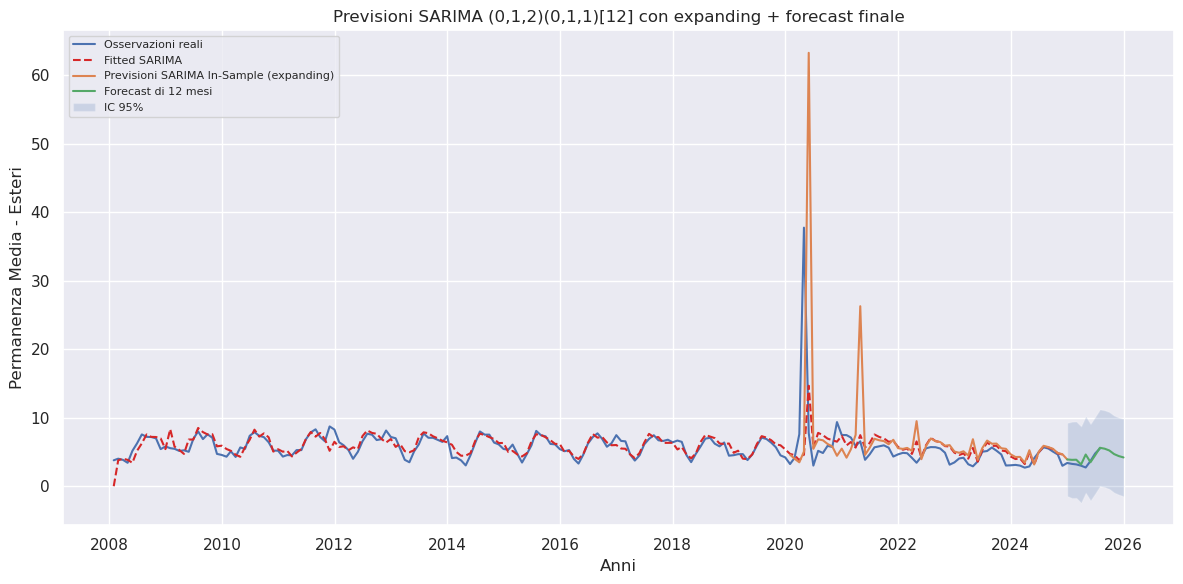

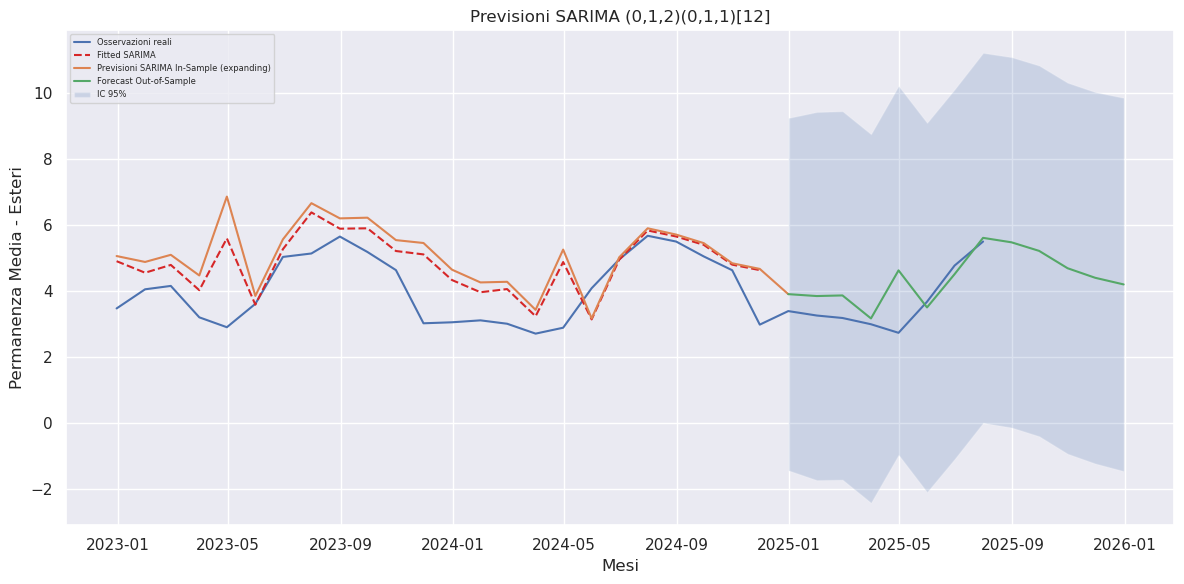

In [7]:
# Parametri

n = len(df)

nV = 60
nT = n - nV

sarima_order   = (0, 1, 2)
seasonal_order = (0, 1, 1, 12)

print(f"Numero di osservazioni: {n}")
print(f"Punti in expanding-test: {nV}")

# Expanding Window solo sul Validation Set

y_true_list = []
y_pred_list = []
lower_list  = []
upper_list  = []
idx_list    = []

for t in range(nT, n):
    train_window = df.iloc[:t]

    model = SARIMAX(
        train_window,
        order=sarima_order,
        seasonal_order=seasonal_order,
        trend='n',
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False)

    fc = res.get_forecast(steps=1)
    y_hat = fc.predicted_mean.iloc[0]
    ci = fc.conf_int(alpha=0.05)

    y_true_list.append(df.iloc[t])
    y_pred_list.append(y_hat)
    lower_list.append(ci.iloc[0, 0])
    upper_list.append(ci.iloc[0, 1])
    idx_list.append(df.index[t])

# Serie expanding sul validation
y_true_exp = pd.Series(y_true_list, index=idx_list)
y_pred_exp = pd.Series(y_pred_list, index=idx_list)
lower_exp  = pd.Series(lower_list, index=idx_list)
upper_exp  = pd.Series(upper_list, index=idx_list)

# Metriche expanding
metrics_exp = compute_metrics(
    y_true_exp,
    y_pred_exp,
    y_train_scale=df.iloc[:nT],
    m=12
)

# Modello finale e Forecast

future_steps = 13
final_model = SARIMAX(
    df[:203],
    order=sarima_order,
    seasonal_order=seasonal_order,
    trend='n',
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_res = final_model.fit(disp=False)
fitted_final = final_res.fittedvalues
fitted_final = fitted_final.dropna()

future_fc = final_res.get_forecast(steps=future_steps)
y_future  = future_fc.predicted_mean
ci_future = future_fc.conf_int(alpha=0.05)

lower_future = ci_future.iloc[:, 0]
upper_future = ci_future.iloc[:, 1]

print("\nPrevisioni sul validation set:")
print(y_pred_exp)
print("\nPrevisioni future:")
print(y_future[1:])

# Plot

plt.figure(figsize=(12, 6))

# Osservazioni reali
plt.plot(df1.index, df1.values, label='Osservazioni reali')
# Fitted values
plt.plot(fitted_final.index,
         fitted_final.values,
         linestyle="--",
         color="tab:red",
         label="Fitted SARIMA")
# Previsioni expanding sul validation
plt.plot(y_pred_exp.index, y_pred_exp.values, label='Previsioni SARIMA In-Sample (expanding)')
plt.plot(y_future.index, y_future.values, label='Forecast di 12 mesi')
# Banda di confidenza 95%
plt.fill_between(y_future.index, lower_future, upper_future, alpha=0.2, label='IC 95%')
plt.title("Previsioni SARIMA (0,1,2)(0,1,1)[12] con expanding + forecast finale")
plt.xlabel("Anni")
plt.ylabel("Permanenza Media - Esteri")
plt.legend(loc="upper left", fontsize =  8)
plt.tight_layout()
plt.savefig("Plot/pme_sarima_expanding.png", dpi=300, bbox_inches="tight")
plt.show()

# Zoom

plt.figure(figsize=(12, 6))
df_plot = df1.iloc[179:]
y_pred_plot = y_pred_exp.iloc[35:60]
fitted_final = fitted_final.iloc[179:]

plt.plot(df_plot.index, df_plot.values, label='Osservazioni reali')
plt.plot(fitted_final.index,
         fitted_final.values,
         linestyle="--",
         color="tab:red",
         label="Fitted SARIMA")
plt.plot(y_pred_plot.index, y_pred_plot.values, label='Previsioni SARIMA In-Sample (expanding)')
plt.plot(y_future.index, y_future.values, label='Forecast Out-of-Sample')
plt.fill_between(y_future.index, lower_future, upper_future, alpha=0.2, label='IC 95%')
plt.title("Previsioni SARIMA (0,1,2)(0,1,1)[12]")
plt.xlabel("Mesi")
plt.ylabel("Permanenza Media - Esteri")
plt.legend(loc = "upper left", fontsize = 6)
plt.tight_layout()
plt.savefig("Plot/pme_sarima_expanding_zoom.png", dpi=300, bbox_inches="tight")
plt.show()

# Salvataggio risultati

metrics_df = pd.DataFrame([metrics_exp])
file_path = os.path.join("Metrics", "sarima_expanding_permanenza_media_esteri_metrics.csv")
metrics_df.to_csv(file_path, index=False)

forecasts_df = pd.DataFrame({"forecast": y_future[1:]})
file_path = os.path.join("Forecasts", "sarima_expanding_permanenza_media_esteri_forecasts.csv")
forecasts_df.to_csv(file_path, index=False)

## Setup - Reti neurali

In [8]:
def create_sequences(data, window_size):
    """
    data: array 1D (già scalato)
    ritorna X (n, window, 1) e y (n,)
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size])
    X = np.array(X, dtype=np.float32).reshape(-1, window_size, 1)
    y = np.array(y, dtype=np.float32)
    return X, y

## LSTM pura

2026-04-01 18:53:32.780787: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



Metriche sul test set:
MAE = 1.797  MSE = 22.439  RMSE = 4.737  MAPE = 26.59%  sMAPE = 24.37%
    95% CI MAE  : [0.949, 3.128]
    95% CI MSE  : [1.699, 59.820]
    95% CI RMSE : [1.303, 7.734]
    95% CI MAPE : [19.99, 34.46]
    95% CI sMAPE: [18.72, 31.01]


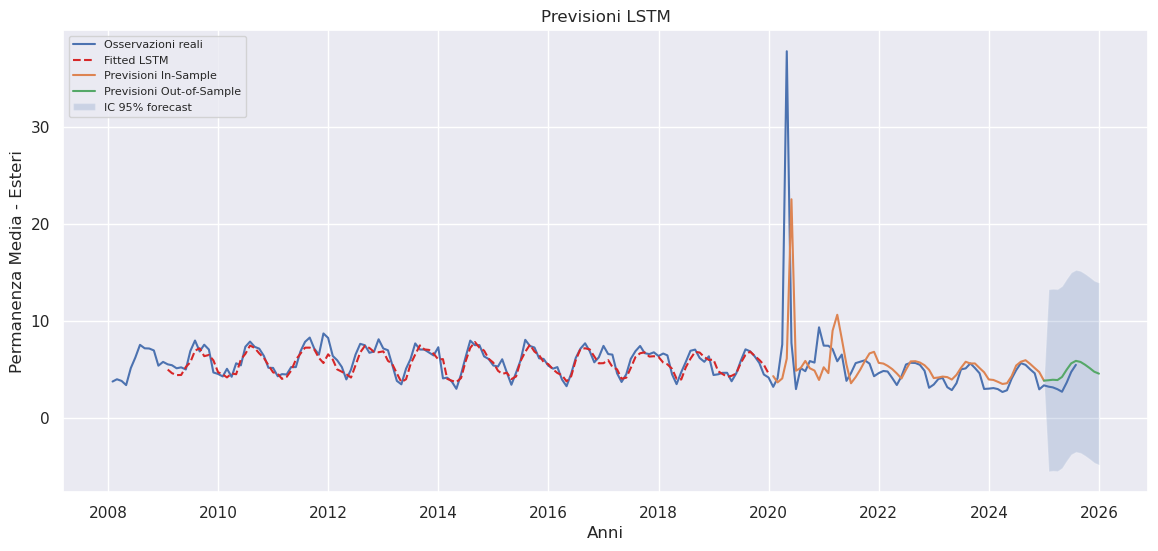

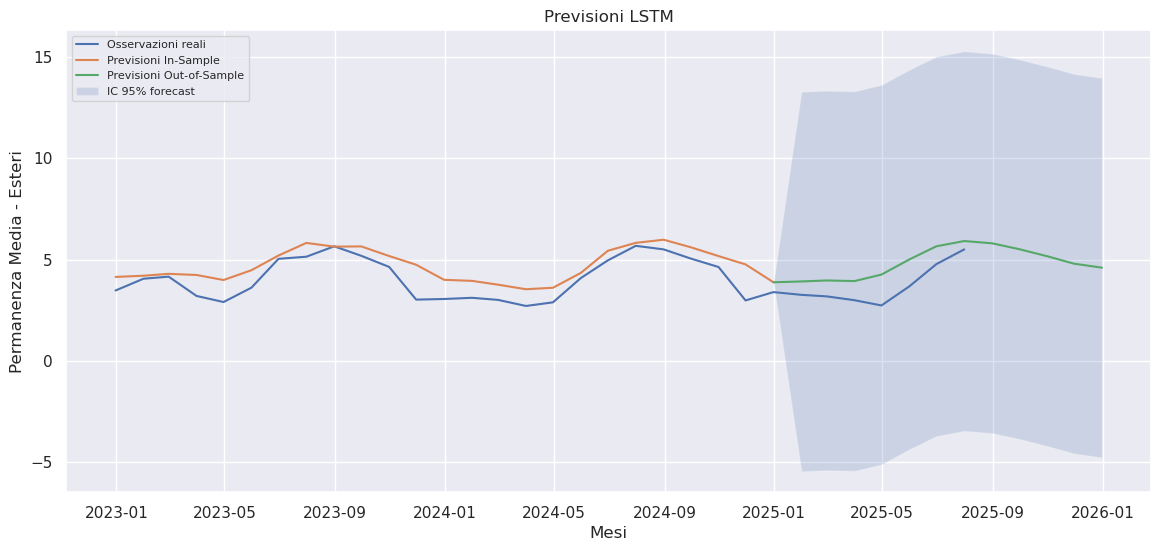

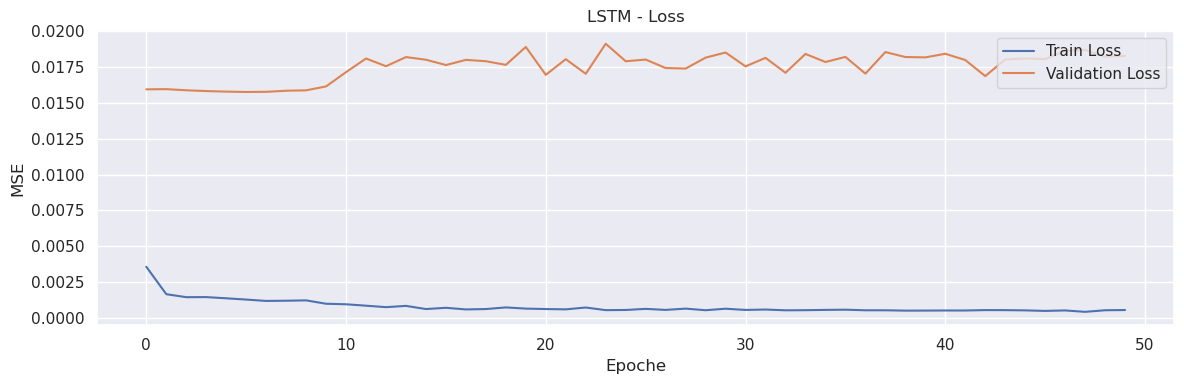


Forecast futuri :
    forecast
0   3.920811
1   3.969867
2   3.939178
3   4.259108
4   5.005821
5   5.655056
6   5.914211
7   5.801782
8   5.514020
9   5.167300
10  4.797434
11  4.600501

Veri Valori: 
2025-01-31    3.260817
2025-02-28    3.185995
2025-03-31    2.996539
2025-04-30    2.736436
2025-05-31    3.678055
2025-06-30    4.774827
2025-07-31    5.502449
Freq: ME


In [9]:
# Parametri 

window_size    = 12               # dimensione finestra LSTM
test_ratio     = 0.2              # quota dati per test
epochs         = 50               # epoche LSTM
batch_size     = 16               # batch size LSTM
learning_rt    = 0.01             # learning rate
steps_ahead    = 12               # step futuri da prevedere

# Serie di Input

y_series = pd.Series(df).copy()

serie = y_series.values.astype(np.float32)
dates = y_series.index  # per eventuale uso date nella visualizzazione

# Scaling + Sequenze
scaler = MinMaxScaler(feature_range=(0, 1))
serie_scaled = scaler.fit_transform(serie.reshape(-1, 1)).flatten()

X, y = create_sequences(serie_scaled, window_size)
split_idx = 132
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# valori reali corrispondenti al test (in scala originale)
# y_test corrisponde a serie[window_size + split_idx : window_size + len(X)]
y_true_test = serie[window_size + split_idx : window_size + len(X)]

# indici temporali del test
test_index = dates[window_size + split_idx : window_size + len(X)]

# LSTM 

model = Sequential([
    LSTM(64, input_shape=(window_size, 1)),  # LSTM base
    Dropout(0.2),                            # regolarizzazione
    Dense(1)
])

model.compile(optimizer=Nadam(learning_rate=learning_rt), loss="mse")

history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    shuffle=False,
    verbose=0
)

# Predizione sul test e inversione dello scaling

y_pred_scaled = model.predict(X_test, verbose=0).flatten()

y_pred_test = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

# serie predetta sul test con indice temporale corretto
y_pred_test_series = pd.Series(y_pred_test, index=test_index)

# Predizione sul training set
y_pred_train_scaled = model.predict(X_train, verbose=0).flatten()
y_pred_train = scaler.inverse_transform(y_pred_train_scaled.reshape(-1, 1)).flatten()

# valori reali del training set in scala originale
y_true_train = serie[window_size : window_size + split_idx]

# indice temporale corretto del training set
train_index = dates[window_size : window_size + split_idx]

# serie predetta sul training con indice temporale corretto
y_pred_train_series = pd.Series(y_pred_train, index=train_index)
y_true_train_series = pd.Series(y_true_train, index=train_index)

# Metriche

print("\nMetriche sul test set:")
metrics_dict = compute_metrics(y_true_test, y_pred_test)

# Forecast Multi-Step

# usa l'ultima finestra della serie scalata
last_window = serie_scaled[-window_size:].copy()
future_scaled = []
input_seq = last_window.copy()

for _ in range(steps_ahead):
    x_in = input_seq.reshape(1, window_size, 1)
    pred = model.predict(x_in, verbose=0)[0, 0]
    future_scaled.append(pred)
    input_seq = np.roll(input_seq, -1)
    input_seq[-1] = pred

future_pred = scaler.inverse_transform(np.array(future_scaled).reshape(-1, 1)).flatten()

# Intervalli di confidenza per il forecast futuro (approssimazione normale)
residuals_test = y_true_test - y_pred_test
sigma = np.std(residuals_test, ddof=1)
z = 1.96

lower_future = future_pred - z * sigma
upper_future = future_pred + z * sigma

# crea indice futuro
future_index = pd.date_range(start=dates[-1] + pd.offsets.MonthEnd(1), periods=steps_ahead, freq='M')

future_pred_series = pd.Series(future_pred, index=future_index)
lower_future_series = pd.Series(lower_future, index=future_index)
upper_future_series = pd.Series(upper_future, index=future_index)

# Plot

# serie reale completa

plt.figure(figsize=(14, 6))
y_pred_plot = y_pred_test_series
forecast_plot_index = y_pred_plot.index[-1:].append(future_pred_series.index)
forecast_plot_values = np.r_[y_pred_plot.iloc[-1], future_pred_series.values]
lower_plot = np.r_[y_pred_plot.iloc[-1], lower_future_series.values]
upper_plot = np.r_[y_pred_plot.iloc[-1], upper_future_series.values]

plt.plot(df1.index, df1.values, label="Osservazioni reali")
plt.plot(y_pred_train_series.index, y_pred_train_series.values, linestyle="--", color="tab:red", label="Fitted LSTM")

# previsioni sul test set
plt.plot(y_pred_test_series.index, y_pred_test_series.values, label="Previsioni In-Sample")

# forecast futuro
plt.plot(forecast_plot_index, forecast_plot_values, label="Previsioni Out-of-Sample")

# Bande di confidenza
plt.fill_between(
    forecast_plot_index,
    lower_plot,
    upper_plot,
    alpha=0.2,
    label="IC 95% forecast"
)

plt.title("Previsioni LSTM")
plt.xlabel("Anni")
plt.ylabel("Permanenza Media - Esteri")
plt.legend(loc="upper left", fontsize = 8)
plt.savefig("Plot/pme_lstm.png", dpi=300, bbox_inches="tight")
plt.show()

### Plot con zoom sulla parte di test + forecast

df_plot = df1.iloc[179:]
y_pred_plot = y_pred_test_series.iloc[35:]

plt.figure(figsize=(14, 6))
plt.plot(df_plot.index, df_plot.values, label="Osservazioni reali")
plt.plot(y_pred_plot.index, y_pred_plot.values, label="Previsioni In-Sample")

# forecast futuro
plt.plot(forecast_plot_index, forecast_plot_values, label="Previsioni Out-of-Sample")

# Bande di confidenza
plt.fill_between(
    forecast_plot_index,
    lower_plot,
    upper_plot,
    alpha=0.2,
    label="IC 95% forecast"
)

plt.title("Previsioni LSTM")
plt.xlabel("Mesi")
plt.ylabel("Permanenza Media - Esteri")
plt.legend(loc="upper left", fontsize = 8)
plt.savefig("Plot/pme_lstm_zoom.png", dpi=300, bbox_inches="tight")
plt.show()

# Loss training/validation
plt.figure(figsize=(12, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM - Loss")
plt.xlabel("Epoche")
plt.ylabel("MSE")
plt.legend(loc = "upper right")
plt.tight_layout()
plt.savefig("Plot/pme_lstm_validation.png", dpi=300, bbox_inches="tight")
plt.show()

# Salvataggio risultati

metrics_df = pd.DataFrame([metrics_dict])
file_path = os.path.join("Metrics", "lstm_permanenza_media_esteri_metrics.csv")
metrics_df.to_csv(file_path, index=False)

forecasts_df = pd.DataFrame({"forecast": future_pred})
file_path = os.path.join("Forecasts", "lstm_permanenza_media_esteri_forecasts.csv")
forecasts_df.to_csv(file_path, index=False)
print("\nForecast futuri :")
print(forecasts_df)
print("\nVeri Valori: ")
print(df1[204:211].to_string())

### Hybrid SARIMA - LSTM


METRICHE - IBRIDO SARIMA+LSTM
MAE = 1.052  MSE = 2.247  RMSE = 1.499  MAPE = 30.74%  sMAPE = 37.71%
    95% CI MAE  : [0.410, 1.868]
    95% CI MSE  : [0.250, 5.219]
    95% CI RMSE : [0.500, 2.285]
    95% CI MAPE : [11.30, 55.35]
    95% CI sMAPE: [11.36, 79.54]


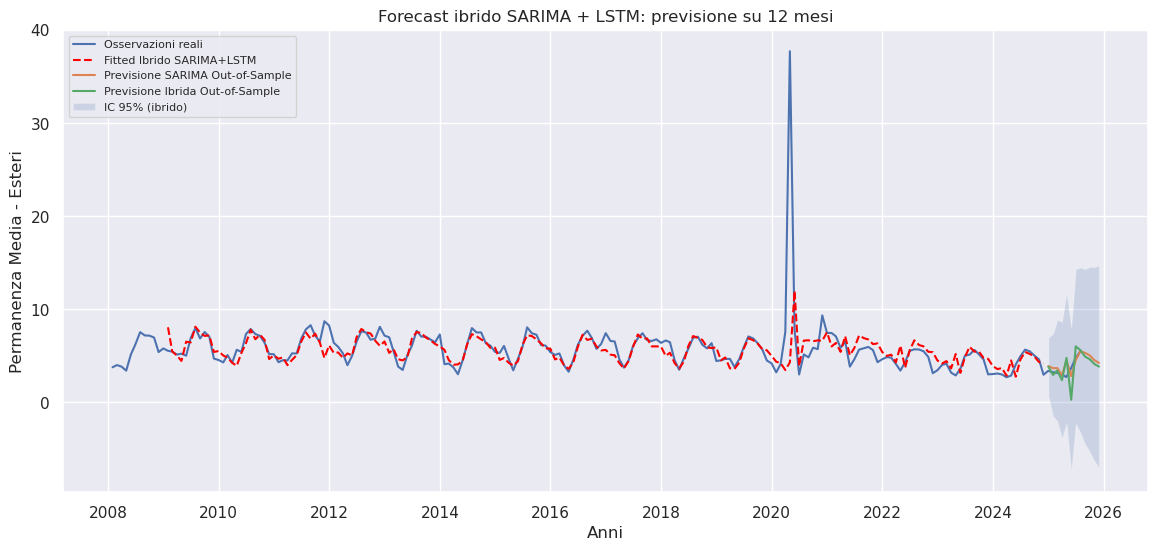

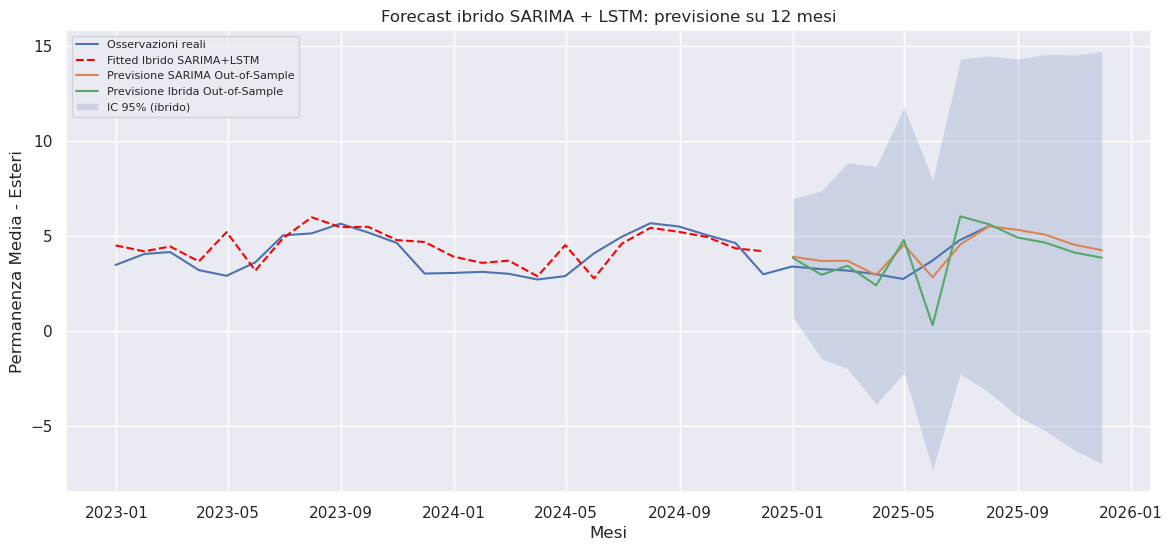

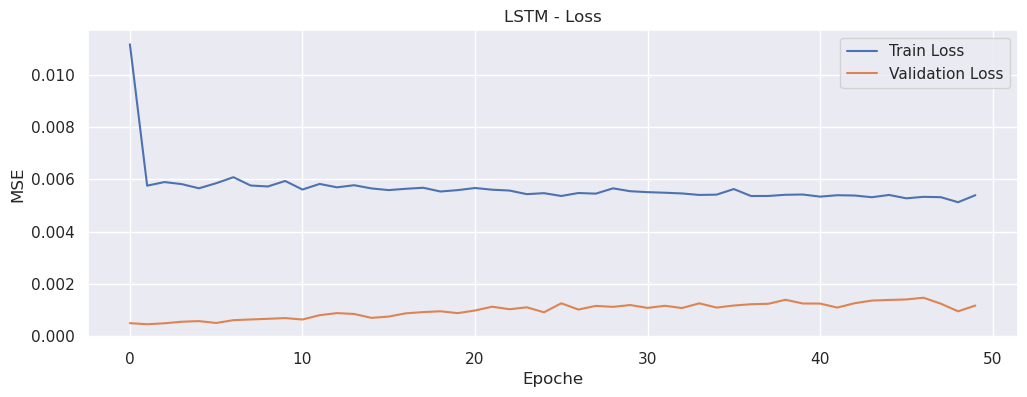


Forecast futuri: 
    forecast
0   3.845530
1   2.960145
2   3.436316
3   2.402408
4   4.796472
5   0.299591
6   6.036801
7   5.621135
8   4.920142
9   4.651851
10  4.133766
11  3.859657

Veri Valori: 
2025-01-31    3.260817
2025-02-28    3.185995
2025-03-31    2.996539
2025-04-30    2.736436
2025-05-31    3.678055
2025-06-30    4.774827
2025-07-31    5.502449
Freq: ME


In [10]:
# Parametri di Split

n_sviluppo = 203
n_forecast_totale = 12  # Vogliamo 12 mesi in totale
n_confronto_reale = 7   # Di cui solo 7 hanno il dato reale per il confronto
idx_test_start = n_sviluppo

# Parametri Modelli
sarima_order   = (0, 1, 2)
seasonal_order = (0, 1, 1, 12)
window_size    = 12
epochs         = 50
batch_size     = 8
learning_rt    = 0.001
update_epochs  = 10

# Preparazione dei dati per LSTM (solo sviluppo)
dev_series = df1.iloc[:n_sviluppo].astype(float)


# Fit SARIMA iniziale per ottenere i residui su cui addestrare la LSTM
sarima_init = SARIMAX(
    dev_series,
    order=sarima_order,
    seasonal_order=seasonal_order,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

resid_dev = (dev_series - sarima_init.fittedvalues).dropna()

# Scaling (fit solo su sviluppo)
scaler_res = MinMaxScaler(feature_range=(0, 1))
resid_dev_scaled = scaler_res.fit_transform(resid_dev.values.reshape(-1, 1)).flatten()

# Creazione sequenze per LSTM
X_dev, y_dev = create_sequences(resid_dev_scaled, window_size)

# Split 80/20 dell'area di sviluppo per addestramento e validazione della LSTM
split_idx = int(len(X_dev) * 0.8)
X_tr, X_val = X_dev[:split_idx], X_dev[split_idx:]
y_tr, y_val = y_dev[:split_idx], y_dev[split_idx:]

# Reshape esplicito se create_sequences non lo fa già
X_tr = X_tr.reshape((X_tr.shape[0], X_tr.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))

# Architettura e train LSTM
model_res = Sequential([
    LSTM(100, activation="tanh", return_sequences=False, input_shape=(window_size, 1)),
    Dropout(0.2),
    Dense(25, activation="relu"),
    Dense(1),
])

model_res.compile(
    optimizer=Nadam(learning_rate=learning_rt),
    loss="mse"
)

history = model_res.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=0
)

# Expanding e Out-of-Sample Forecast ibrido SARIMA + LSTM
y_true_list, y_sarima_list, y_hybrid_list = [], [], []
lower_list, upper_list, idx_list = [], [], []

forecast_dates = pd.date_range(
    start=df1.index[idx_test_start],
    periods=n_forecast_totale,
    freq='MS'
)

# Variabile di supporto per la finestra dei residui quando finiscono i dati reali
current_resid_scaled = list(resid_dev_scaled)

for i in range(n_forecast_totale):
    t = idx_test_start + i
    current_date = forecast_dates[i]

    # Gestione dati reali vs forecast puro
    if t < len(df1):
        train_window = df1.iloc[:t].astype(float)
        y_true = float(df1.iloc[t])
    else:
        train_window = df1.astype(float)
        y_true = np.nan

    # SARIMA forecast
    res_s = SARIMAX(
        train_window,
        order=sarima_order,
        seasonal_order=seasonal_order,
        trend="n",
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    steps_ahead = 1 if t < len(df1) else (t - len(df1) + 1)
    fc = res_s.get_forecast(steps=steps_ahead)
    y_hat_sarima = float(fc.predicted_mean.iloc[-1])
    ci = fc.conf_int(alpha=0.05).iloc[-1:]

    # Previsione residuo con LSTM
    last_window_res = np.array(current_resid_scaled[-window_size:]).reshape(1, window_size, 1)
    resid_hat_scaled = float(model_res.predict(last_window_res, verbose=0)[0, 0])
    resid_hat = float(scaler_res.inverse_transform([[resid_hat_scaled]])[0, 0])

    # Combinazione
    y_hat_hybrid = y_hat_sarima + resid_hat

    # Aggiornamento residui + fine-tuning online della LSTM
    if not np.isnan(y_true):
        # Nuovo residuo osservato
        new_resid = y_true - y_hat_sarima
        new_resid_scaled = scaler_res.transform([[new_resid]])[0, 0]
        current_resid_scaled.append(new_resid_scaled)

        # Creazione nuove sequenze aggiornate
        updated_array = np.array(current_resid_scaled)
        X_up, y_up = create_sequences(updated_array, window_size)

        # Reshape per LSTM
        X_up = X_up.reshape((X_up.shape[0], X_up.shape[1], 1))

        # Fine-tuning solo sull'ultima sequenza disponibile
        model_res.fit(
            X_up[-1:],
            y_up[-1:],
            epochs=update_epochs,
            verbose=0
        )
    else:
        # Auto-alimentazione del residuo predetto oltre il campione osservato
        current_resid_scaled.append(resid_hat_scaled)

    # Salvataggio
    y_true_list.append(y_true)
    y_sarima_list.append(y_hat_sarima)
    y_hybrid_list.append(y_hat_hybrid)
    lower_list.append(float(ci.iloc[0, 0]) + resid_hat)
    upper_list.append(float(ci.iloc[0, 1]) + resid_hat)
    idx_list.append(current_date)

y_true_exp   = pd.Series(y_true_list, index=idx_list)
y_sarima_exp = pd.Series(y_sarima_list, index=idx_list)
y_hybrid_exp = pd.Series(y_hybrid_list, index=idx_list)
lower_95     = pd.Series(lower_list, index=idx_list)
upper_95     = pd.Series(upper_list, index=idx_list)

# fitted SARIMA sullo sviluppo
sarima_fitted_dev = sarima_init.fittedvalues.copy()

# residui usati per la LSTM
# resid_dev = (dev_series - sarima_init.fittedvalues).dropna()

# predizione LSTM sui residui (solo dove esistono le sequenze)
X_dev_lstm = X_dev.reshape((X_dev.shape[0], X_dev.shape[1], 1))
resid_pred_scaled = model_res.predict(X_dev_lstm, verbose=0).flatten()
resid_pred_lstm = scaler_res.inverse_transform(resid_pred_scaled.reshape(-1, 1)).flatten()

# indice corretto dei fitted LSTM sui residui
# la prima previsione LSTM parte dopo window_size osservazioni dei residui
resid_lstm_index = resid_dev.index[window_size:]

resid_fitted_series = pd.Series(resid_pred_lstm, index=resid_lstm_index)

# fitted ibridi = fitted SARIMA + fitted LSTM dei residui
hybrid_fitted_dev = sarima_fitted_dev.loc[resid_lstm_index] + resid_fitted_series

# valori reali corrispondenti
y_true_fitted_dev = dev_series.loc[resid_lstm_index]

# Metriche
mask = ~y_true_exp.isna()

print("\nMETRICHE - IBRIDO SARIMA+LSTM")
metrics_hybrid = compute_metrics(y_true_exp[mask], y_hybrid_exp[mask])

# Bande predittive approssimate per il forecast multi-step
residuals_test = y_true_exp[mask] - y_hybrid_exp[mask]
sigma = np.std(residuals_test, ddof=1)
z = 1.96

horizons = np.arange(1, len(y_hybrid_exp) + 1)
sigma_h = sigma * np.sqrt(horizons)

lower_future_series = pd.Series(
    y_hybrid_exp.values - z * sigma_h,
    index=y_hybrid_exp.index
)

upper_future_series = pd.Series(
    y_hybrid_exp.values + z * sigma_h,
    index=y_hybrid_exp.index
)

# Plot

plt.figure(figsize=(14, 6))
plt.plot(df1.index, df1.values, label="Osservazioni reali", lw=1.5)

# fitted ibridi
plt.plot(hybrid_fitted_dev.index, hybrid_fitted_dev.values, linestyle="--", color="red", label="Fitted Ibrido SARIMA+LSTM", lw=1.5)

plt.plot(y_sarima_exp.index, y_sarima_exp.values, label="Previsione SARIMA Out-of-Sample")
plt.plot(y_hybrid_exp.index, y_hybrid_exp.values, label="Previsione Ibrida Out-of-Sample")
plt.fill_between(
    y_hybrid_exp.index,
    lower_future_series.values,
    upper_future_series.values,
    alpha=0.20,
    label="IC 95% (ibrido)"
)
plt.title("Forecast ibrido SARIMA + LSTM: previsione su 12 mesi")
plt.xlabel("Anni")
plt.ylabel("Permanenza Media - Esteri")
plt.legend(loc = "upper left", fontsize = 8)
plt.savefig("Plot/pme_sarima_lstm.png", dpi=300, bbox_inches="tight")
plt.show()

# Zoom

plt.figure(figsize=(14, 6))
df_hist = df1.iloc[179:211]
hybrid_fitted_dev_plot = hybrid_fitted_dev.iloc[167:]

plt.plot(df_hist.index, df_hist.values, label="Osservazioni reali", lw=1.5)
plt.plot(hybrid_fitted_dev_plot.index, hybrid_fitted_dev_plot.values, linestyle="--", color="red", label="Fitted Ibrido SARIMA+LSTM", lw=1.5)
plt.plot(y_sarima_exp.index, y_sarima_exp.values, label="Previsione SARIMA Out-of-Sample")
plt.plot(y_hybrid_exp.index, y_hybrid_exp.values, label="Previsione Ibrida Out-of-Sample")
plt.fill_between(
    y_hybrid_exp.index,
    lower_future_series.values, 
    upper_future_series.values, 
    alpha=0.20, 
    label="IC 95% (ibrido)")
plt.title("Forecast ibrido SARIMA + LSTM: previsione su 12 mesi")
plt.xlabel("Mesi")
plt.ylabel("Permanenza Media - Esteri")
plt.legend(loc = "upper left", fontsize = 8)
plt.savefig("Plot/pme_sarima_lstm_zoom.png", dpi=300, bbox_inches="tight")
plt.show()

# Loss training/validation LSTM

plt.figure(figsize=(12, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM - Loss")
plt.xlabel("Epoche")
plt.ylabel("MSE")
plt.legend(loc = "upper right")
plt.savefig("Plot/pme_sarima_lstm_validation.png", dpi=300, bbox_inches="tight")
plt.grid(True)
plt.show()

# Salvataggio risultati

metrics_df = pd.DataFrame([metrics_hybrid])
file_path = os.path.join("Metrics", "sarima_lstm_permanenza_media_esteri_metrics.csv")
metrics_df.to_csv(file_path, index=False)

forecasts_df = pd.DataFrame({"forecast": y_hybrid_list})
file_path = os.path.join("Forecasts", "sarima_lstm_permanenza_media_esteri_forecasts.csv")
forecasts_df.to_csv(file_path, index=False)
print("\nForecast futuri: ")
print(forecasts_df)
print("\nVeri Valori: ")
print(df1[204:211].to_string())

### Hybrid SARIMA - GRU


METRICHE - IBRIDO SARIMA + GRU
MAE = 1.186  MSE = 2.910  RMSE = 1.706  MAPE = 33.50%  sMAPE = 40.16%
    95% CI MAE  : [0.402, 2.109]
    95% CI MSE  : [0.566, 6.094]
    95% CI RMSE : [0.751, 2.469]
    95% CI MAPE : [10.57, 59.87]
    95% CI sMAPE: [10.31, 84.68]


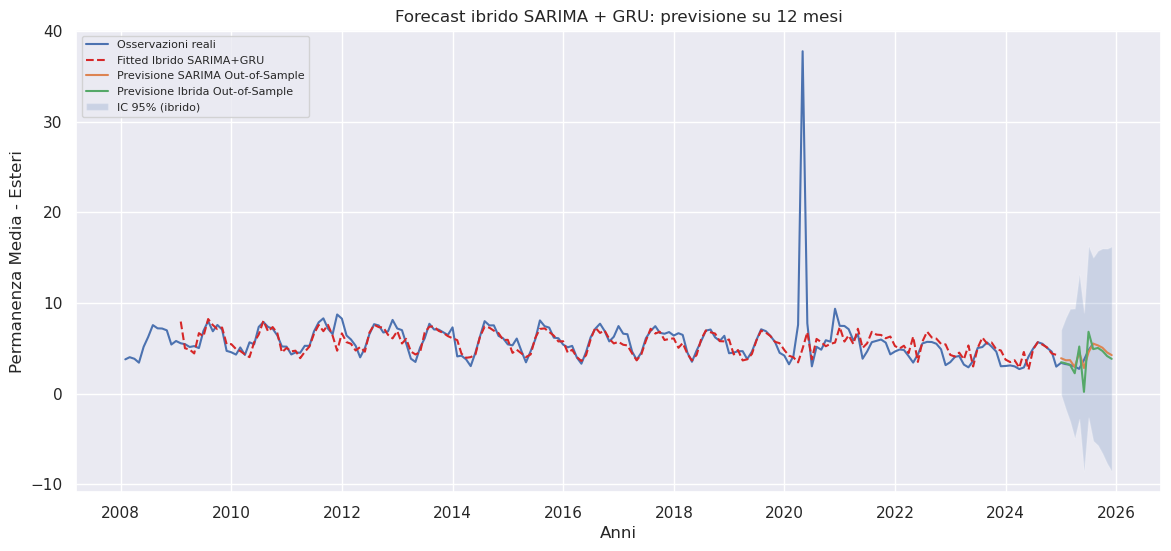

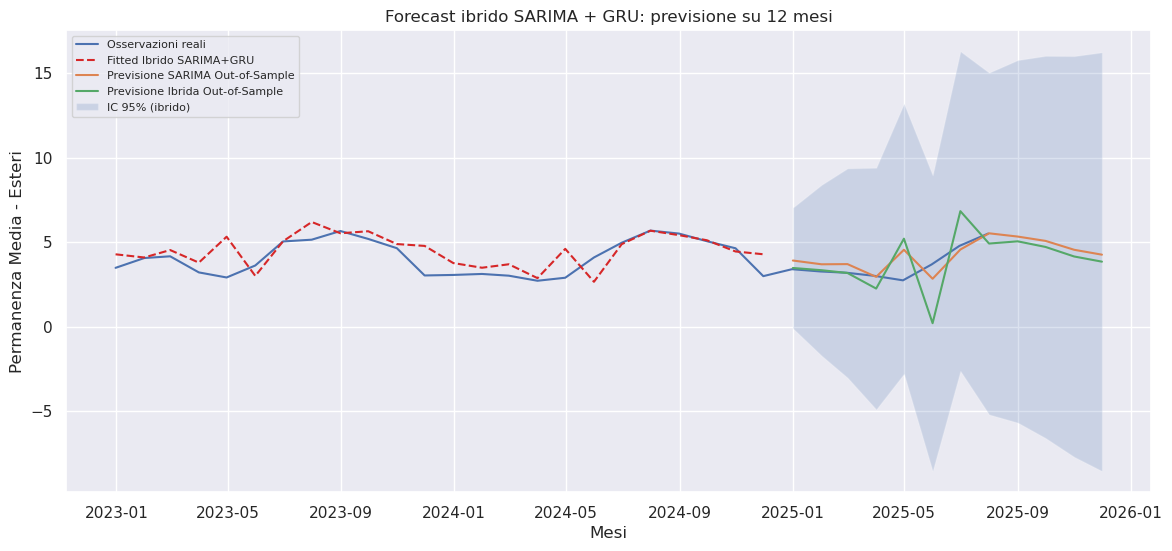

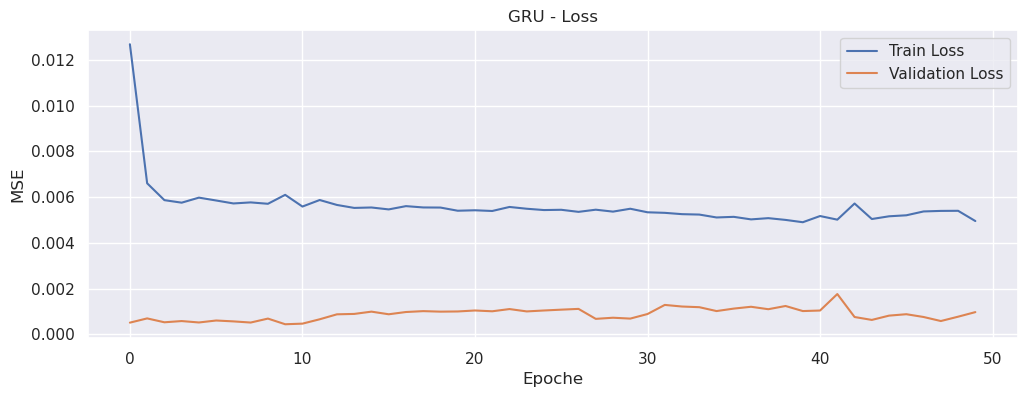


Forecast futuri: 
    forecast
0   3.467531
1   3.335434
2   3.171409
3   2.250688
4   5.199915
5   0.201781
6   6.827912
7   4.912325
8   5.043268
9   4.712108
10  4.147236
11  3.841267

Veri Valori: 
2025-01-31    3.260817
2025-02-28    3.185995
2025-03-31    2.996539
2025-04-30    2.736436
2025-05-31    3.678055
2025-06-30    4.774827
2025-07-31    5.502449
Freq: ME


In [11]:
# Preparazione dati

n_sviluppo = 203
idx_test_start = n_sviluppo

dev_series = df1.iloc[:n_sviluppo].astype(float)

sarima_order   = (0, 1, 2)
seasonal_order = (0, 1, 1, 12)
window_size    = 12
epochs         = 50
batch_size     = 16
learning_rt    = 0.01
update_epochs  = 5

sarima_init = SARIMAX(
    dev_series,
    order=sarima_order,
    seasonal_order=seasonal_order,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

resid_dev = (dev_series - sarima_init.fittedvalues).dropna()
scaler_res = MinMaxScaler(feature_range=(0, 1))
resid_dev_scaled = scaler_res.fit_transform(resid_dev.values.reshape(-1, 1)).flatten()

X_dev, y_dev = create_sequences(resid_dev_scaled, window_size)

# Split 80/20 per validation interna
split_idx = int(len(X_dev) * 0.8)
X_tr, X_val = X_dev[:split_idx], X_dev[split_idx:]
y_tr, y_val = y_dev[:split_idx], y_dev[split_idx:]

# Architettura GRU

model_res = Sequential([
    GRU(100, activation="tanh", return_sequences=False, input_shape=(window_size, 1)),
    Dropout(0.2),
    Dense(25, activation="relu"),
    Dense(1),
])
model_res.compile(optimizer=Nadam(learning_rate=learning_rt), loss="mse")

history = model_res.fit(X_tr, y_tr, validation_data=(X_val, y_val), 
              epochs=epochs, batch_size=batch_size, verbose=0)

# Expanding + Out-of-Sample Forecast ibrido SARIMA + GRU
y_true_list, y_sarima_list, y_hybrid_list = [], [], []
lower_list, upper_list, idx_list = [], [], []

forecast_dates = pd.date_range(start=df1.index[idx_test_start], periods=12, freq='MS')
current_resid_scaled = list(resid_dev_scaled)

for i in range(12):
    t = idx_test_start + i
    current_date = forecast_dates[i]
    
    # Dati Reali vs Forecast
    if t < len(df1):
        train_window = df1.iloc[:t].astype(float)
        y_true = float(df1.iloc[t])
    else:
        train_window = df1.astype(float)
        y_true = np.nan
    
    # SARIMA Refit/Forecast
    res_s = SARIMAX(
        train_window,
        order=sarima_order,
        seasonal_order=seasonal_order,
        trend="n",
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)
    
    steps_ahead = 1 if t < len(df1) else (t - len(df1) + 1)
    fc = res_s.get_forecast(steps=steps_ahead)
    y_hat_sarima = float(fc.predicted_mean.iloc[-1])
    ci = fc.conf_int(alpha=0.05).iloc[-1:]
    
    # Previsione Residuo con GRU
    last_window_res = np.array(current_resid_scaled[-window_size:]).reshape(1, window_size, 1)
    resid_hat_scaled = float(model_res.predict(last_window_res, verbose=0)[0, 0])
    resid_hat = float(scaler_res.inverse_transform([[resid_hat_scaled]])[0, 0])
    
    # Combinazione ed aggiornamento
    y_hat_hybrid = y_hat_sarima + resid_hat
    
    if not np.isnan(y_true):
        # Update con errore reale
        new_resid = y_true - y_hat_sarima
        new_resid_scaled = scaler_res.transform([[new_resid]])[0, 0]
        current_resid_scaled.append(new_resid_scaled)
        # Piccolo fine-tuning della GRU sui nuovi dati
        X_up, y_up = create_sequences(np.array(current_resid_scaled), window_size)
        model_res.fit(X_up[-1:], y_up[-1:], epochs=update_epochs, verbose=0) 
    else:
        # Auto-alimentazione del residuo
        current_resid_scaled.append(resid_hat_scaled)

    y_true_list.append(y_true)
    y_sarima_list.append(y_hat_sarima)
    y_hybrid_list.append(y_hat_hybrid)
    lower_list.append(float(ci.iloc[0, 0]) + resid_hat)
    upper_list.append(float(ci.iloc[0, 1]) + resid_hat)
    idx_list.append(current_date)

y_true_exp   = pd.Series(y_true_list, index=idx_list)
y_sarima_exp = pd.Series(y_sarima_list, index=idx_list)
y_hybrid_exp = pd.Series(y_hybrid_list, index=idx_list)
lower_95     = pd.Series(lower_list, index=idx_list)
upper_95     = pd.Series(upper_list, index=idx_list)

# fitted SARIMA sul campione di sviluppo
sarima_fitted_dev = sarima_init.fittedvalues.copy()

# predizione GRU sui residui in-sample
X_dev_in = X_dev.reshape((X_dev.shape[0], X_dev.shape[1], 1))
resid_pred_scaled = model_res.predict(X_dev_in, verbose=0).flatten()
resid_pred = scaler_res.inverse_transform(resid_pred_scaled.reshape(-1, 1)).flatten()

# indice temporale corretto:
# la GRU può predire solo dopo window_size residui iniziali
resid_pred_index = resid_dev.index[window_size:]

# serie dei residui predetti
resid_pred_series = pd.Series(resid_pred, index=resid_pred_index)

# fitted ibrido = fitted SARIMA + residuo previsto dalla GRU
hybrid_fitted_dev = sarima_fitted_dev.loc[resid_pred_index] + resid_pred_series

# valori reali corrispondenti
y_true_fitted_dev = dev_series.loc[resid_pred_index]

# Metriche
# Calcola le metriche solo dove y_true non è NaN
mask = ~y_true_exp.isna()

print("\nMETRICHE - IBRIDO SARIMA + GRU")
metrics_hybrid = compute_metrics(y_true_exp[mask], y_hybrid_exp[mask])

# Bande predittive approssimate per il forecast multi-step
residuals_test = y_true_exp[mask] - y_hybrid_exp[mask]
sigma = np.std(residuals_test, ddof=1)
z = 1.96

# orizzonte completo della previsione: 12 mesi
horizons = np.arange(1, len(y_hybrid_exp) + 1)
sigma_h = sigma * np.sqrt(horizons)

lower_future_series = pd.Series(
    y_hybrid_exp.values - z * sigma_h,
    index=y_hybrid_exp.index
)

upper_future_series = pd.Series(
    y_hybrid_exp.values + z * sigma_h,
    index=y_hybrid_exp.index
)

# Plot

plt.figure(figsize=(14, 6))
plt.plot(df1.index, df1.values, label="Osservazioni reali", lw=1.5)
hybrid_fit_plot = hybrid_fitted_dev
plt.plot(hybrid_fit_plot.index, hybrid_fit_plot.values, linestyle = '--', color = "tab:red" , label="Fitted Ibrido SARIMA+GRU", lw=1.5)
plt.plot(y_sarima_exp.index, y_sarima_exp.values, label="Previsione SARIMA Out-of-Sample")
plt.plot(y_hybrid_exp.index, y_hybrid_exp.values, label="Previsione Ibrida Out-of-Sample")
plt.fill_between(
    y_hybrid_exp.index,
    lower_future_series.values, 
    upper_future_series.values, 
    alpha=0.20, 
    label="IC 95% (ibrido)")
plt.title("Forecast ibrido SARIMA + GRU: previsione su 12 mesi")
plt.xlabel("Anni")
plt.ylabel("Permanenza Media - Esteri")
plt.legend(loc = "upper left", fontsize = 8)
plt.savefig("Plot/pme_sarima_gru.png", dpi=300, bbox_inches="tight")
plt.show()

# Zoom

plt.figure(figsize=(14, 6))
df_hist = df1.iloc[179:211]
hybrid_fit_plot = hybrid_fit_plot.iloc[167:]

plt.plot(df_hist.index, df_hist.values, label="Osservazioni reali", lw=1.5)
plt.plot(hybrid_fit_plot.index, hybrid_fit_plot.values, linestyle = '--', color = "tab:red" , label="Fitted Ibrido SARIMA+GRU", lw=1.5)
plt.plot(y_sarima_exp.index, y_sarima_exp.values, label="Previsione SARIMA Out-of-Sample")
plt.plot(y_hybrid_exp.index, y_hybrid_exp.values, label="Previsione Ibrida Out-of-Sample")
plt.fill_between(
    y_hybrid_exp.index,
    lower_future_series.values, 
    upper_future_series.values, 
    alpha=0.20, 
    label="IC 95% (ibrido)")
plt.title("Forecast ibrido SARIMA + GRU: previsione su 12 mesi")
plt.xlabel("Mesi")
plt.ylabel("Permanenza Media - Esteri")
plt.legend(loc = "upper left", fontsize = 8)
plt.savefig("Plot/pme_sarima_gru_zoom.png", dpi=300, bbox_inches="tight")
plt.show()

# Zoom training/validation loss

plt.figure(figsize=(12, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("GRU - Loss")
plt.xlabel("Epoche")
plt.ylabel("MSE")
plt.legend(loc = "upper right")
plt.savefig("Plot/pme_sarima_gru_validation.png", dpi=300, bbox_inches="tight")
plt.grid(True)
plt.show()

# Salvataggio risultati

metrics_df = pd.DataFrame([metrics_hybrid])
file_path = os.path.join("Metrics", "sarima_gru_permanenza_media_esteri_metrics.csv")
metrics_df.to_csv(file_path, index=False)

forecasts_df = pd.DataFrame({"forecast": y_hybrid_list})
file_path = os.path.join("Forecasts", "sarima_gru_permanenza_media_esteri_forecasts.csv")
forecasts_df.to_csv(file_path, index=False)
print("\nForecast futuri: ")
print(forecasts_df)
print("\nVeri Valori: ")
print(df1[204:211].to_string())

### Hybrid SARIMA - N-BEATS


METRICHE - IBRIDO SARIMA + N-BEATS
MAE = 0.853  MSE = 1.537  RMSE = 1.240  MAPE = 24.91%  sMAPE = 21.56%
    95% CI MAE  : [0.429, 1.557]
    95% CI MSE  : [0.211, 4.017]
    95% CI RMSE : [0.459, 2.004]
    95% CI MAPE : [11.68, 45.87]
    95% CI sMAPE: [11.45, 34.83]


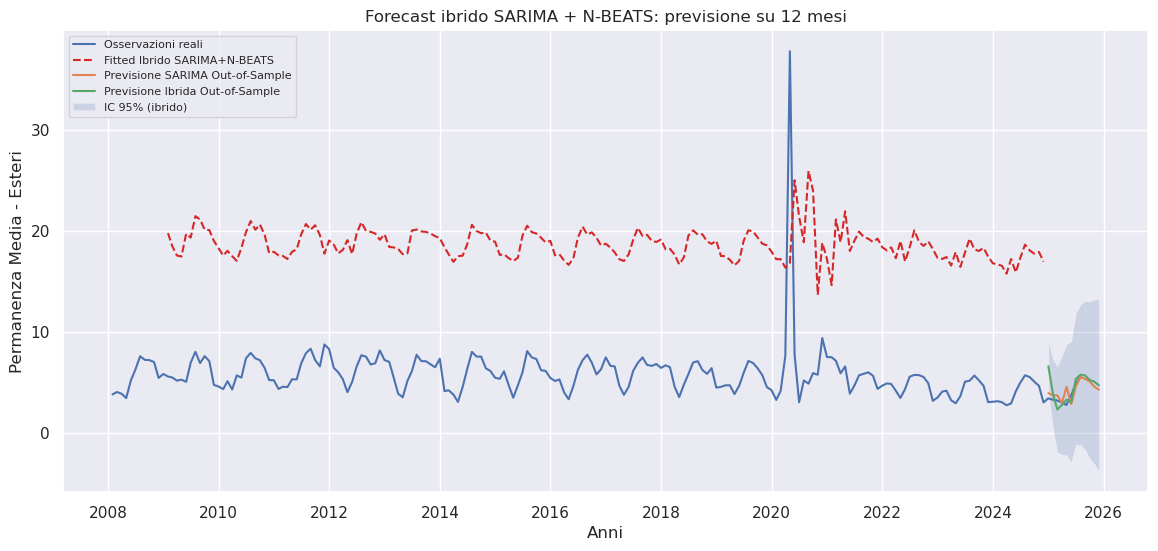

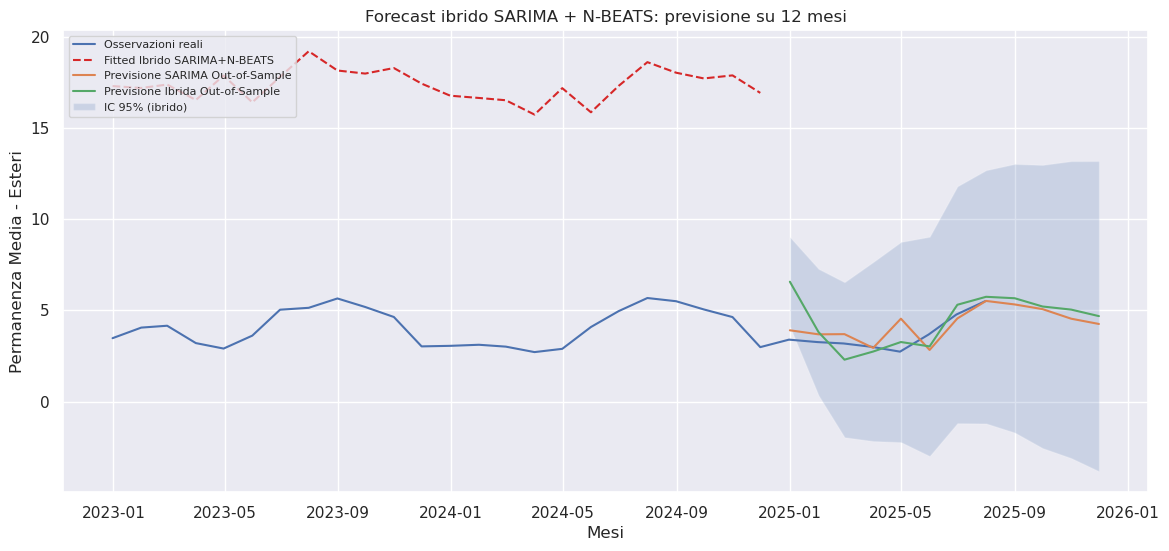


Forecast futuri: 
    forecast
0   6.571902
1   3.806187
2   2.296178
3   2.742521
4   3.264399
5   3.025008
6   5.307959
7   5.744674
8   5.665913
9   5.213406
10  5.042976
11  4.685077

Veri Valori: 
2025-01-31    3.260817
2025-02-28    3.185995
2025-03-31    2.996539
2025-04-30    2.736436
2025-05-31    3.678055
2025-06-30    4.774827
2025-07-31    5.502449
Freq: ME


In [12]:
n_sviluppo = 203
idx_test_start = n_sviluppo

sarima_order   = (0, 1, 2)
seasonal_order = (0, 1, 1, 12)
window_size    = 12
epochs         = 50
batch_size     = 16
learning_rt    = 0.01
update_epochs  = 10

# Architettura N-BEATS robusta

def nbeats_block(input_layer, window_size):
    x = layers.Dense(128, activation='relu')(input_layer)
    #x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation='relu')(x)
    #x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation='relu')(x)
    #x = layers.Dropout(0.2)(x)
    backcast = layers.Dense(window_size, activation='linear')(x)
    forecast = layers.Dense(1, activation='linear')(x)
    return backcast, forecast

def build_nbeats(window_size, n_blocks=3):
    input_layer = layers.Input(shape=(window_size,))
    res_input = input_layer
    stack_forecasts = []
    
    for _ in range(n_blocks):
        backcast, forecast = nbeats_block(res_input, window_size)
        res_input = layers.Subtract()([res_input, backcast])
        stack_forecasts.append(forecast)
            
    final_forecast = layers.Add()(stack_forecasts) if len(stack_forecasts) > 1 else stack_forecasts[0]
    model = Model(inputs=input_layer, outputs=final_forecast)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return model

# Preparazione e parametri per N-BEATS
window_size = 12
n_forecast_totale = 12  # Orizzonte richiesto
idx_test_start = n_sviluppo # Il punto dove iniziano i tuoi 7 mesi reali
model_res = build_nbeats(window_size)

y_true_list, y_sarima_list, y_hybrid_list = [], [], []
idx_list = []

# Generiamo le date per i 12 mesi di forecast
forecast_dates = pd.date_range(start=df1.index[idx_test_start], periods=n_forecast_totale, freq='MS')

# Buffer per i residui (necessario per alimentare N-BEATS nel forecast puro)
# Inizializziamo con i residui dello sviluppo
res_init = SARIMAX(df1.iloc[:idx_test_start], order=sarima_order, seasonal_order=seasonal_order).fit(disp=False)
current_resid_list = list((df1.iloc[:idx_test_start].values.flatten() - res_init.fittedvalues.values.flatten())[window_size:])

# Fitted SARIMA in-sample
fitted_sarima_insample = res_init.fittedvalues  # già disponibile da res_init

# Residui in-sample SARIMA
residui_insample = df1.iloc[:idx_test_start].values.flatten() - fitted_sarima_insample.values.flatten()

# Costruzione sequenze per N-BEATS in-sample
# Per ogni posizione t in [window_size, idx_test_start), uso la finestra
# di residui precedenti per predire il residuo in t

scaler_is = MinMaxScaler(feature_range=(-1, 1))
residui_scaled_is = scaler_is.fit_transform(residui_insample.reshape(-1, 1)).flatten()

fitted_nbeats_residui = []
idx_insample = []

for t in range(window_size, idx_test_start):
    window = residui_scaled_is[t - window_size:t].reshape(1, window_size)
    pred_scaled = float(model_res.predict(window, verbose=0)[0, 0])
    pred = float(scaler_is.inverse_transform([[pred_scaled]])[0, 0])
    fitted_nbeats_residui.append(pred)
    idx_insample.append(df1.index[t])

fitted_nbeats_residui = np.array(fitted_nbeats_residui)

# Fitted ibrido in-sample
fitted_sarima_slice = fitted_sarima_insample.iloc[window_size:].values
fitted_hybrid_insample = pd.Series(
    fitted_sarima_slice + fitted_nbeats_residui,
    index=idx_insample
)
fitted_sarima_insample_plot = pd.Series(
    fitted_sarima_slice,
    index=idx_insample
)

# Forecast mese per mese, aggiornando il modello e i residui ad ogni step
for i in range(n_forecast_totale):
    t = idx_test_start + i
    current_date = forecast_dates[i]
    
    # Gestione Dati Reali vs Future
    if t < len(df1):
        train_window = df1.iloc[:t].astype(float)
        y_real = float(df1.iloc[t])
    else:
        train_window = df1.astype(float) # Usiamo tutto il disponibile
        y_real = np.nan # Non abbiamo il confronto
    
    # SARIMA Refit & Forecast
    # Per il forecast puro, chiediamo n passi avanti rispetto all'ultimo dato reale
    steps_ahead = 1 if t < len(df1) else (t - len(df1) + 1)
    
    res_s = SARIMAX(train_window, order=sarima_order, seasonal_order=seasonal_order, 
                    trend="n", enforce_stationarity=False).fit(disp=False)
    y_hat_sarima = float(res_s.get_forecast(steps=steps_ahead).predicted_mean.iloc[-1])
    
    # Update N-BEATS (solo se abbiamo dati reali per calcolare nuovi residui)
    # Scaliamo i residui storici
    scaler_up = MinMaxScaler(feature_range=(-1, 1))
    resid_arr = np.array(current_resid_list).reshape(-1, 1)
    resid_scaled = scaler_up.fit_transform(resid_arr).flatten()
    
    if not np.isnan(y_real):
        # Update incrementale del modello con l'ultimo errore commesso
        # Creiamo X_up dagli ultimi residui disponibili
        X_up = resid_scaled[-window_size:].reshape(1, window_size)
        y_up = scaler_up.transform([[y_real - y_hat_sarima]])[0]
        model_res.fit(X_up, y_up, epochs=update_epochs, verbose=0)
        
        # Aggiungiamo il nuovo residuo reale alla lista
        current_resid_list.append(y_real - y_hat_sarima)
    
    # Forecast Residuo con N-BEATS
    last_window_scaled = resid_scaled[-window_size:].reshape(1, window_size)
    resid_hat_scaled = float(model_res.predict(last_window_scaled, verbose=0)[0, 0])
    resid_hat = float(scaler_up.inverse_transform([[resid_hat_scaled]])[0, 0])
    
    # Se siamo nel forecast puro, aggiungiamo il residuo predetto per i passi successivi
    if np.isnan(y_real):
        current_resid_list.append(resid_hat)
    
    # Combinazione Finale
    y_hat_hybrid = y_hat_sarima + resid_hat
    
    y_true_list.append(y_real)
    y_sarima_list.append(y_hat_sarima)
    y_hybrid_list.append(y_hat_hybrid)
    idx_list.append(current_date)

# Salvataggio
y_true_exp   = pd.Series(y_true_list, index=idx_list)
y_sarima_exp = pd.Series(y_sarima_list, index=idx_list)
y_hybrid_exp = pd.Series(y_hybrid_list, index=idx_list)

# Metriche 
mask = ~y_true_exp.isna()

print("\nMETRICHE - IBRIDO SARIMA + N-BEATS")
metrics_hybrid = compute_metrics(y_true_exp[mask], y_hybrid_exp[mask])

# Bande predittive approssimate per il forecast multi-step
residuals_test = y_true_exp[mask] - y_hybrid_exp[mask]
sigma = np.std(residuals_test, ddof=1)
z = 1.96

# orizzonte completo della previsione: 12 mesi
horizons = np.arange(1, len(y_hybrid_exp) + 1)
sigma_h = sigma * np.sqrt(horizons)

lower_future_series = pd.Series(
    y_hybrid_exp.values - z * sigma_h,
    index=y_hybrid_exp.index
)

upper_future_series = pd.Series(
    y_hybrid_exp.values + z * sigma_h,
    index=y_hybrid_exp.index
)

# Plot

plt.figure(figsize=(14, 6))
plt.plot(df1.index, df1.values, label="Osservazioni reali", lw=1.5)
plt.plot(fitted_hybrid_insample.index, fitted_hybrid_insample.values,
         label="Fitted Ibrido SARIMA+N-BEATS", linestyle="--", color= "tab:red", lw=1.5)
plt.plot(y_sarima_exp.index, y_sarima_exp.values, label="Previsione SARIMA Out-of-Sample")
plt.plot(y_hybrid_exp.index, y_hybrid_exp.values, label="Previsione Ibrida Out-of-Sample")
plt.fill_between(
    y_hybrid_exp.index,
    lower_future_series.values, 
    upper_future_series.values, 
    alpha=0.20, 
    label="IC 95% (ibrido)")
plt.title("Forecast ibrido SARIMA + N-BEATS: previsione su 12 mesi")
plt.xlabel("Anni")
plt.ylabel("Permanenza Media - Esteri")
plt.legend(loc = "upper left", fontsize = 8)
plt.savefig("Plot/pme_sarima_nbeats.png", dpi=300, bbox_inches="tight")
plt.show()

# Zoom

plt.figure(figsize=(14, 6))
df_hist = df1.iloc[179:211]
fitted_hybrid_insample = fitted_hybrid_insample.iloc[167:]
plt.plot(df_hist.index, df_hist.values, label="Osservazioni reali", lw=1.5)
plt.plot(fitted_hybrid_insample.index, fitted_hybrid_insample.values,
         label="Fitted Ibrido SARIMA+N-BEATS", linestyle="--", color= "tab:red", lw=1.5)
plt.plot(y_sarima_exp.index, y_sarima_exp.values, label="Previsione SARIMA Out-of-Sample")
plt.plot(y_hybrid_exp.index, y_hybrid_exp.values, label="Previsione Ibrida Out-of-Sample")
plt.fill_between(
    y_hybrid_exp.index,
    lower_future_series.values, 
    upper_future_series.values, 
    alpha=0.20, 
    label="IC 95% (ibrido)")
plt.title("Forecast ibrido SARIMA + N-BEATS: previsione su 12 mesi")
plt.xlabel("Mesi")
plt.ylabel("Permanenza Media - Esteri")
plt.legend(loc = "upper left", fontsize = 8)
plt.savefig("Plot/pme_sarima_nbeats_zoom.png", dpi=300, bbox_inches="tight")
plt.show()

# Salvataggio risultati

metrics_df = pd.DataFrame([metrics_hybrid])
file_path = os.path.join("Metrics", "sarima_nbeats_permanenza_media_esteri_metrics.csv")
metrics_df.to_csv(file_path, index=False)

forecasts_df = pd.DataFrame({"forecast": y_hybrid_list})
file_path = os.path.join("Forecasts", "sarima_nbeats_permanenza_media_esteri_forecasts.csv")
forecasts_df.to_csv(file_path, index=False)
print("\nForecast futuri: ")
print(forecasts_df)
print("\nVeri Valori: ")
print(df1[204:211].to_string())

### Hybrid SARIMA - Transformer


METRICHE - IBRIDO SARIMA + TRANSFORMER
MAE = 0.745  MSE = 0.992  RMSE = 0.996  MAPE = 20.86%  sMAPE = 21.24%
    95% CI MAE  : [0.337, 1.234]
    95% CI MSE  : [0.252, 1.996]
    95% CI RMSE : [0.502, 1.413]
    95% CI MAPE : [8.47, 35.30]
    95% CI sMAPE: [8.17, 38.31]


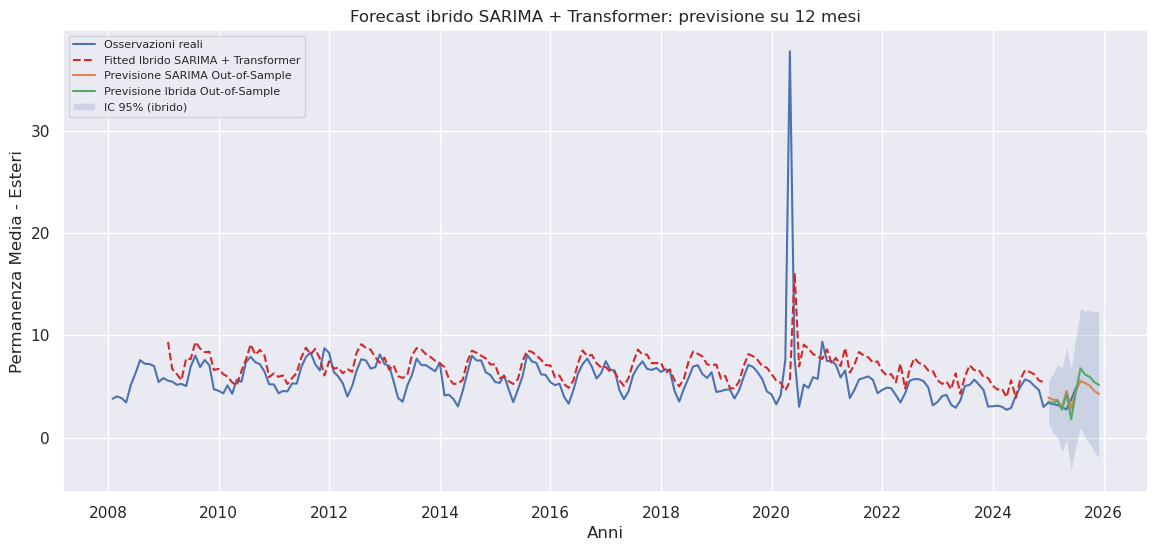

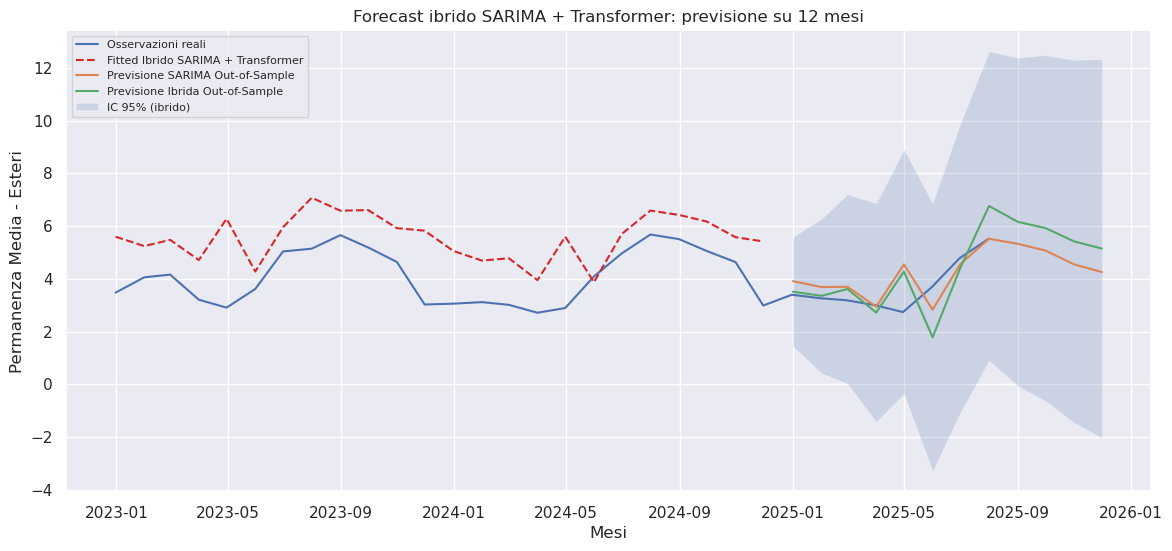


Forecast futuri: 
    forecast
0   3.511398
1   3.351635
2   3.613400
3   2.718538
4   4.271132
5   1.782803
6   4.416381
7   6.760107
8   6.160014
9   5.921948
10  5.416556
11  5.145253

Veri Valori: 
2025-01-31    3.260817
2025-02-28    3.185995
2025-03-31    2.996539
2025-04-30    2.736436
2025-05-31    3.678055
2025-06-30    4.774827
2025-07-31    5.502449
Freq: ME


In [13]:
n_sviluppo = 203
start_test = n_sviluppo

dev_series = df1.iloc[:n_sviluppo].astype(float)

sarima_order   = (0, 1, 2)
seasonal_order = (0, 1, 1, 12)
window_size    = 12
epochs         = 50
batch_size     = 16
learning_rt    = 0.001
update_epochs  = 10
n_forecast_totale = 12
online_epochs = 5          # epoche di aggiornamento online
online_batch_size = 1      # update leggero sull'ultima sequenza

# Architettura Transformer
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.0):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs

    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)

    return x + res

def build_transformer_model(window_size):
    inputs = layers.Input(shape=(window_size, 1))

    x = transformer_encoder(
        inputs,
        head_size=64,
        num_heads=4,
        ff_dim=64,
        dropout=0.1
    )
    x = transformer_encoder(
        x,
        head_size=64,
        num_heads=4,
        ff_dim=64,
        dropout=0.1
    )

    x = layers.GlobalAveragePooling1D(data_format="channels_last")(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(1)(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )
    return model

# Preparazione dati iniziali
forecast_dates = pd.date_range(
    start=df1.index[start_test],
    periods=n_forecast_totale,
    freq="MS"
)

# SARIMA iniziale sui dati di sviluppo
res_init = SARIMAX(
    df1.iloc[:start_test].astype(float),
    order=sarima_order,
    seasonal_order=seasonal_order,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# Residui iniziali per il training del Transformer
resid_train = (
    df1.iloc[:start_test].values.flatten() -
    res_init.fittedvalues.values.flatten()
)

# Scaler fisso: fit solo sui residui di sviluppo
scaler_res = MinMaxScaler(feature_range=(-1, 1))
resid_train_scaled = scaler_res.fit_transform(
    resid_train.reshape(-1, 1)
).flatten()

# Dataset iniziale per Transformer
X_train_res, y_train_res = create_sequences(resid_train_scaled, window_size)

# Reshape esplicito se necessario
X_train_res = X_train_res.reshape((X_train_res.shape[0], X_train_res.shape[1], 1))

# Build e training iniziale
model_res = build_transformer_model(window_size)

history = model_res.fit(
    X_train_res,
    y_train_res,
    epochs=100,
    batch_size=16,
    verbose=0
)

# Forecasting con aggiornamento online
y_true_list, y_sarima_list, y_hybrid_list = [], [], []
lower_list, upper_list, idx_list = [], [], []

# Buffer dinamico dei residui
current_resid_buffer = list(resid_train_scaled)

for i in range(n_forecast_totale):
    t = start_test + i
    current_date = forecast_dates[i]

    # Definizione train window
    if t < len(df1):
        train_window = df1.iloc[:t].astype(float)
        y_true = float(df1.iloc[t])
    else:
        train_window = df1.astype(float)
        y_true = np.nan

    # Refit SARIMA e forecast
    res_s = SARIMAX(
        train_window,
        order=sarima_order,
        seasonal_order=seasonal_order,
        trend="n",
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    steps_ahead = 1 if t < len(df1) else (t - len(df1) + 1)

    fc = res_s.get_forecast(steps=steps_ahead)
    y_hat_sarima = float(fc.predicted_mean.iloc[-1])
    ci = fc.conf_int(alpha=0.05).iloc[-1:]

    # Forecast residuo Transformer
    last_window = np.array(current_resid_buffer[-window_size:]).reshape(1, window_size, 1)
    resid_hat_scaled = float(model_res.predict(last_window, verbose=0)[0, 0])
    resid_hat = float(scaler_res.inverse_transform([[resid_hat_scaled]])[0, 0])

    # Forecast ibrido
    y_hat_hybrid = y_hat_sarima + resid_hat

    # Aggiornamento online
    if not np.isnan(y_true):
        # nuovo residuo osservato
        actual_resid = y_true - y_hat_sarima
        actual_resid_scaled = float(scaler_res.transform([[actual_resid]])[0, 0])

        # aggiorna buffer
        current_resid_buffer.append(actual_resid_scaled)

        # ricrea sequenze aggiornate
        updated_array = np.array(current_resid_buffer)
        X_up, y_up = create_sequences(updated_array, window_size)

        X_up = X_up.reshape((X_up.shape[0], X_up.shape[1], 1))

        # fine-tuning online SOLO sull'ultima sequenza
        model_res.fit(
            X_up[-1:],
            y_up[-1:],
            epochs=online_epochs,
            batch_size=online_batch_size,
            verbose=0
        )

    else:
        # oltre il campione osservato: auto-alimentazione
        current_resid_buffer.append(resid_hat_scaled)

    # Salvataggio risultati
    y_true_list.append(y_true)
    y_sarima_list.append(y_hat_sarima)
    y_hybrid_list.append(y_hat_hybrid)
    lower_list.append(float(ci.iloc[0, 0]) + resid_hat)
    upper_list.append(float(ci.iloc[0, 1]) + resid_hat)
    idx_list.append(current_date)

# Fitted SARIMA in-sample (già disponibili da res_init)
fitted_sarima_insample = res_init.fittedvalues

# Residui in-sample già scalati (calcolati prima del loop)
# resid_train_scaled è disponibile dallo scaler_res fittato sui dati di sviluppo

fitted_transformer_residui = []
idx_insample = []

for t in range(window_size, n_sviluppo):
    window = resid_train_scaled[t - window_size:t].reshape(1, window_size, 1)  # 3D per Transformer
    pred_scaled = float(model_res.predict(window, verbose=0)[0, 0])
    pred = float(scaler_res.inverse_transform([[pred_scaled]])[0, 0])
    fitted_transformer_residui.append(pred)
    idx_insample.append(df1.index[t])

fitted_transformer_residui = np.array(fitted_transformer_residui)

# Fitted ibrido in-sample
fitted_sarima_slice = fitted_sarima_insample.iloc[window_size:].values

fitted_hybrid_insample = pd.Series(
    fitted_sarima_slice + fitted_transformer_residui,
    index=idx_insample
)
fitted_sarima_insample_plot = pd.Series(
    fitted_sarima_slice,
    index=idx_insample
)

# Serie finali
y_true_exp = pd.Series(y_true_list, index=idx_list)
y_sarima_exp = pd.Series(y_sarima_list, index=idx_list)
y_hybrid_exp = pd.Series(y_hybrid_list, index=idx_list)
lower_95 = pd.Series(lower_list, index=idx_list)
upper_95 = pd.Series(upper_list, index=idx_list)

# Metriche
mask = ~y_true_exp.isna()

print("\nMETRICHE - IBRIDO SARIMA + TRANSFORMER")
metrics_hybrid = compute_metrics(y_true_exp[mask], y_hybrid_exp[mask])

# Bande predittive approssimate
residuals_test = y_true_exp[mask] - y_hybrid_exp[mask]
sigma = np.std(residuals_test, ddof=1)
z = 1.96

horizons = np.arange(1, len(y_hybrid_exp) + 1)
sigma_h = sigma * np.sqrt(horizons)

lower_future_series = pd.Series(
    y_hybrid_exp.values - z * sigma_h,
    index=y_hybrid_exp.index
)

upper_future_series = pd.Series(
    y_hybrid_exp.values + z * sigma_h,
    index=y_hybrid_exp.index
)

# Plot

plt.figure(figsize=(14, 6))
plt.plot(df1.index, df1.values, label="Osservazioni reali", lw=1.5)
plt.plot(fitted_hybrid_insample.index, fitted_hybrid_insample.values,
         label="Fitted Ibrido SARIMA + Transformer", linestyle="--", color="tab:red", lw=1.5)
plt.plot(y_sarima_exp.index, y_sarima_exp.values, label="Previsione SARIMA Out-of-Sample")
plt.plot(y_hybrid_exp.index, y_hybrid_exp.values, label="Previsione Ibrida Out-of-Sample")
plt.fill_between(
    y_hybrid_exp.index,
    lower_future_series.values, 
    upper_future_series.values, 
    alpha=0.20, 
    label="IC 95% (ibrido)")
plt.title("Forecast ibrido SARIMA + Transformer: previsione su 12 mesi")
plt.xlabel("Anni")
plt.ylabel("Permanenza Media - Esteri")
plt.legend(loc = "upper left", fontsize = 8)
plt.savefig("Plot/pme_sarima_transformer.png", dpi=300, bbox_inches="tight")
plt.show()

# Zoom

plt.figure(figsize=(14, 6))
df_hist = df1.iloc[179:211]
fitted_hybrid_insample = fitted_hybrid_insample.iloc[167:]

plt.plot(df_hist.index, df_hist.values, label="Osservazioni reali", lw=1.5)
plt.plot(fitted_hybrid_insample.index, fitted_hybrid_insample.values,
         label="Fitted Ibrido SARIMA + Transformer", linestyle="--", color="tab:red", lw=1.5)
plt.plot(y_sarima_exp.index, y_sarima_exp.values, label="Previsione SARIMA Out-of-Sample")
plt.plot(y_hybrid_exp.index, y_hybrid_exp.values, label="Previsione Ibrida Out-of-Sample")
plt.fill_between(
    y_hybrid_exp.index,
    lower_future_series.values, 
    upper_future_series.values, 
    alpha=0.20, 
    label="IC 95% (ibrido)")
plt.title("Forecast ibrido SARIMA + Transformer: previsione su 12 mesi")
plt.xlabel("Mesi")
plt.ylabel("Permanenza Media - Esteri")
plt.legend(loc = "upper left", fontsize = 8)
plt.savefig("Plot/pme_sarima_transformer_zoom.png", dpi=300, bbox_inches="tight")
plt.show()

# Salvataggio risultati

metrics_df = pd.DataFrame([metrics_hybrid])
file_path = os.path.join("Metrics", "sarima_transformer_permanenza_media_esteri_metrics.csv")
metrics_df.to_csv(file_path, index=False)

forecasts_df = pd.DataFrame({"forecast": y_hybrid_list})
file_path = os.path.join("Forecasts", "sarima_transformer_permanenza_media_esteri_forecasts.csv")
forecasts_df.to_csv(file_path, index=False)
print("\nForecast futuri: ")
print(forecasts_df)
print("\nVeri Valori: ")
print(df1[204:211].to_string())

## Confronto tra plot

### SARIMA vs LSTM

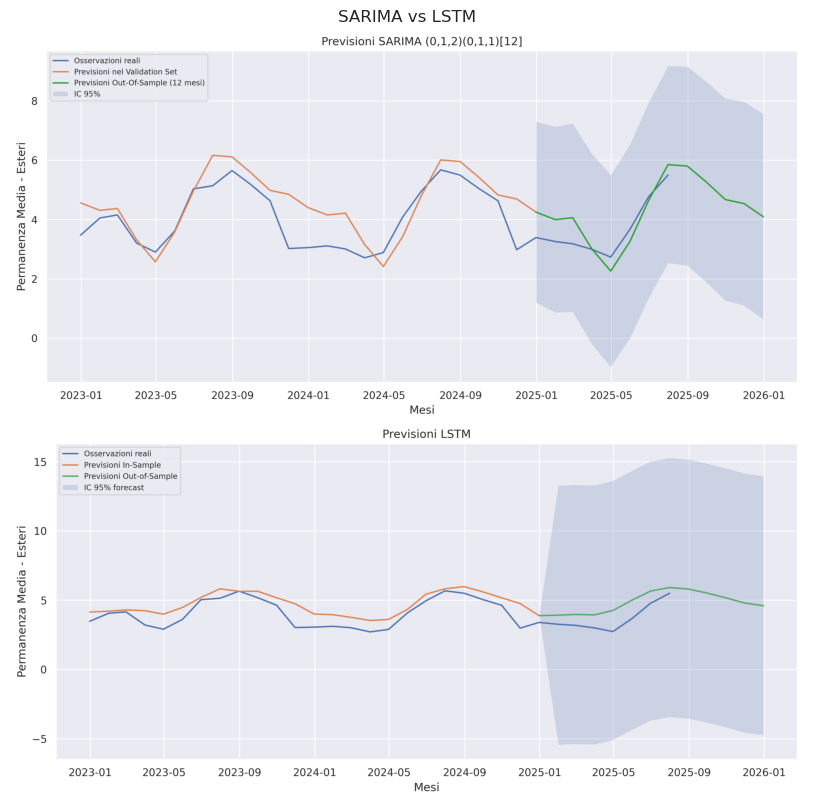

In [14]:
img1_path = os.path.join("Plot", "pme_sarima_zoom.png")
img2_path = os.path.join("Plot", "pme_lstm_zoom.png")

img1 = Image.open(img1_path).convert("RGB")
img2 = Image.open(img2_path).convert("RGB")

w = min(img1.width, img2.width)
img1 = img1.resize((w, int(img1.height * w / img1.width)))
img2 = img2.resize((w, int(img2.height * w / img2.width)))

# collage verticale
collage = Image.new("RGB", (w, img1.height + img2.height), "white")
collage.paste(img1, (0, 0))
collage.paste(img2, (0, img1.height))

plt.figure(figsize=(14, 10))
plt.imshow(collage)
plt.axis("off")
plt.title("SARIMA vs LSTM")
plt.show()

### SARIMA vs Hybrid SARIMA + LSTM

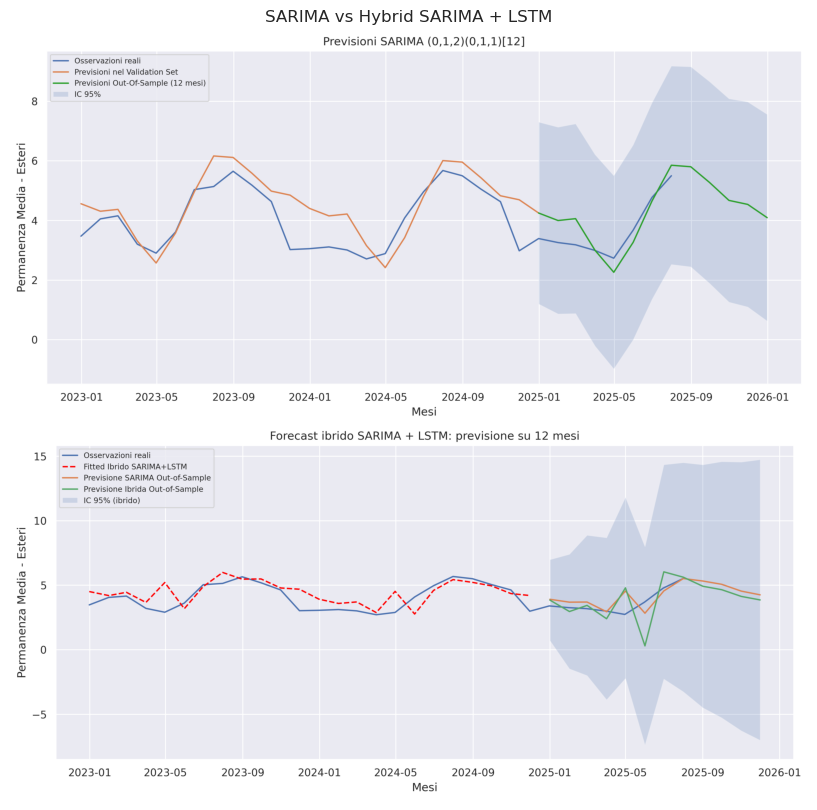

In [15]:
img1_path = os.path.join("Plot", "pme_sarima_zoom.png")
img2_path = os.path.join("Plot", "pme_sarima_lstm_zoom.png")

img1 = Image.open(img1_path).convert("RGB")
img2 = Image.open(img2_path).convert("RGB")

w = min(img1.width, img2.width)
img1 = img1.resize((w, int(img1.height * w / img1.width)))
img2 = img2.resize((w, int(img2.height * w / img2.width)))

# collage verticale
collage = Image.new("RGB", (w, img1.height + img2.height), "white")
collage.paste(img1, (0, 0))
collage.paste(img2, (0, img1.height))

plt.figure(figsize=(14, 10))
plt.imshow(collage)
plt.axis("off")
plt.title("SARIMA vs Hybrid SARIMA + LSTM")
plt.show()

### LSTM + Hybrid SARIMA + LSTM

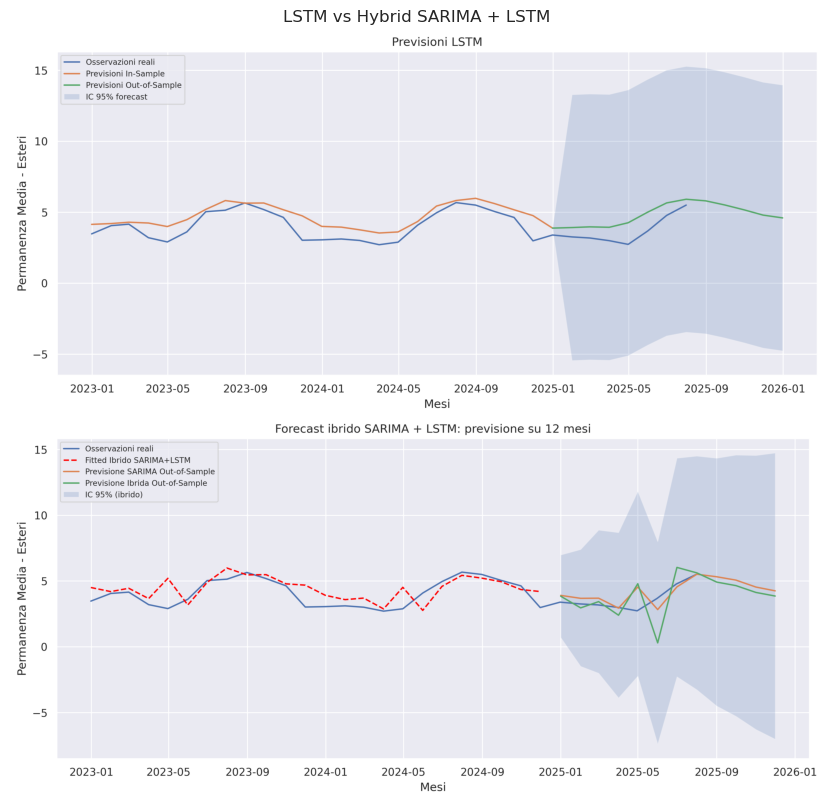

In [16]:
img1_path = os.path.join("Plot", "pme_lstm_zoom.png")
img2_path = os.path.join("Plot", "pme_sarima_lstm_zoom.png")

img1 = Image.open(img1_path).convert("RGB")
img2 = Image.open(img2_path).convert("RGB")

w = min(img1.width, img2.width)
img1 = img1.resize((w, int(img1.height * w / img1.width)))
img2 = img2.resize((w, int(img2.height * w / img2.width)))

# collage verticale
collage = Image.new("RGB", (w, img1.height + img2.height), "white")
collage.paste(img1, (0, 0))
collage.paste(img2, (0, img1.height))

plt.figure(figsize=(14, 10))
plt.imshow(collage)
plt.axis("off")
plt.title("LSTM vs Hybrid SARIMA + LSTM")
plt.show()

### Plot degli hybrid models a confronto

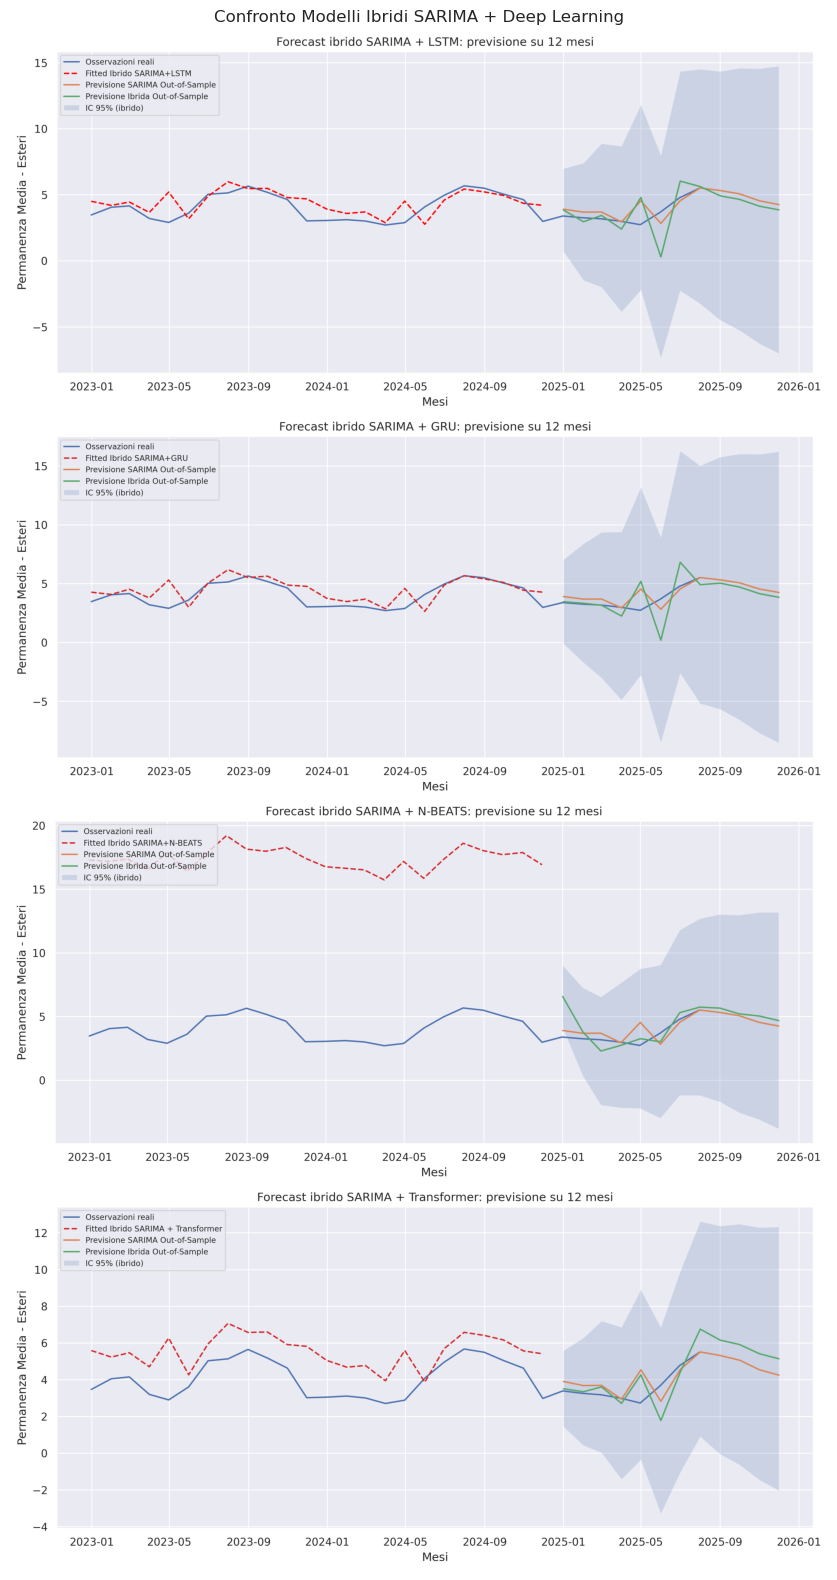

In [17]:
files = [
    "pme_sarima_lstm_zoom.png",
    "pme_sarima_gru_zoom.png",
    "pme_sarima_nbeats_zoom.png",
    "pme_sarima_transformer_zoom.png",
]

paths = [os.path.join("Plot", f) for f in files]

# carica immagini
imgs = [Image.open(p).convert("RGB") for p in paths]

# uniforma la larghezza (mantiene proporzioni)
w = min(im.width for im in imgs)
imgs = [im.resize((w, int(im.height * w / im.width))) for im in imgs]

# crea collage verticale
total_h = sum(im.height for im in imgs)
collage = Image.new("RGB", (w, total_h), "white")

y = 0
for im in imgs:
    collage.paste(im, (0, y))
    y += im.height

# mostra in output
plt.figure(figsize=(14, 20))
plt.imshow(collage)
plt.axis("off")
plt.title("Confronto Modelli Ibridi SARIMA + Deep Learning")
plt.show()